# Tobacco Use Patterns and Secondhand Smoke Exposure in Bangladesh
## Analysis of the Global Adult Tobacco Survey (GATS) 2017

**Course:** CS295 – Programming in Python  
**Semester:** Summer 2026  

**Team Members:**
| Name | Student ID |
|------|-----------|
| *Shayer Mahmud Sowmik* | *2025-3-27-022* |

---

**Dataset:** Bangladesh Global Adult Tobacco Survey (GATS) 2017  
**Source:** World Health Organization (WHO) / Centers for Disease Control and Prevention (CDC)  
**File:** `Bangla_GATS_2017_Public_use_06Spe2018.csv`

---

### Research Rationale and Background

Tobacco use is a leading cause of preventable illness and death worldwide. It causes over 8 million deaths each year (WHO, 2023). In Bangladesh, approximately 35% to 40% of adults consume tobacco products. This high prevalence creates a heavy burden on the national healthcare system.

This project supports **UN Sustainable Development Goal 3 (Good Health and Well-being)**, specifically **Target 3.a**. This target focuses on strengthening the WHO Framework Convention on Tobacco Control (FCTC).

This study examines three main areas:
1. Demographic factors linked to tobacco consumption.
2. Differences between smoked and smokeless tobacco use.
3. Rates and settings of secondhand smoke (SHS) exposure.

The goal is to provide clear empirical evidence. These findings can guide public health policy, targeted cessation programs, and stronger law enforcement.


## Table of Contents

1. [Setup and Data Loading](#1-setup-and-data-loading)
2. [Dataset Overview](#2-dataset-overview)
3. [Data Cleaning and Preprocessing](#3-data-cleaning-and-preprocessing)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
   - 4.1 Overall Tobacco Use Prevalence
   - 4.2 Tobacco Use by Gender
   - 4.3 Tobacco Use by Age Group
   - 4.4 Tobacco Use by Education Level
   - 4.5 Urban vs Rural Differences
   - 4.6 Division-wise Distribution
   - 4.7 Secondhand Smoke Exposure
   - 4.8 Knowledge and Awareness
   - 4.9 Cessation Attempts
   - 4.10 Age Distribution of Tobacco Users (KDE)
   - 4.11 Smoking Initiation Age Analysis
   - 4.12 Correlation Analysis
   - 4.13 Multivariate Exploration
   - 4.14 Summary Statistics Table
5. [Key Findings and Discussion](#5-key-findings-and-discussion)
6. [Policy Implications](#6-policy-implications)
7. [Limitations](#7-limitations)
8. [Conclusion](#8-conclusion)
9. [References](#9-references)


## 1. Setup and Data Loading <a id="1-setup-and-data-loading"></a>

This step imports the required libraries. `pandas` and `numpy` handle data processing. `matplotlib` and `seaborn` generate the charts. Global visual settings are configured for clean presentation.


In [ ]:
# Setup and Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')
sns.set_style('whitegrid')

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [ ]:
# Load Dataset
df = pd.read_csv('Bangla_GATS_2017_Public_use_06Spe2018.csv', low_memory=False)
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


Dataset loaded: 12,783 rows x 516 columns


## 2. Dataset Overview <a id="2-dataset-overview"></a>

The Global Adult Tobacco Survey (GATS) is a nationally representative household survey. It tracks adult tobacco use and key control indicators across Bangladesh.

The main survey sections are summarized below:

| Section | Code Prefix | Description / Domain |
|---------|-------------|----------------------|
| Demographics | A01–A06, AGE | Gender, age, education level, occupation |
| Tobacco Smoking | B01–B18 | Smoking status, daily frequency, initiation age |
| Smokeless Tobacco | C01–C18 | Zarda, sadapata, gul, and khaini usage |
| Cessation | D01–D16 | Quit attempts, cessation methods, clinical advice |
| Secondhand Smoke | E01–E22 | Exposure at home, work, restaurants, transport |
| Economics | F01–FB04 | Prices paid, brand choices, purchase points |
| Media | G01–G06 | Tobacco advertising and anti-tobacco messaging |
| Knowledge | H01–H05 | Public awareness of health risks |


In [ ]:
# Dataset Dimensions and Data Types
print(f"Number of respondents (rows): {df.shape[0]:,}")
print(f"Number of variables (columns): {df.shape[1]}")
print(f"\nColumn data types:")
print(df.dtypes.value_counts())


Number of respondents (rows): 12,783
Number of variables (columns): 516

Column data types:
float64    439
int64       59
str         18
Name: count, dtype: int64


In [ ]:
# Missing Value Analysis
total_cells = df.shape[0] * df.shape[1]
missing_cells = df.isnull().sum().sum()
print(f"Total cells in dataset: {total_cells:,}")
print(f"Missing cells: {missing_cells:,}")
print(f"Overall missing percentage: {missing_cells / total_cells * 100:.2f}%")
print(f"\nColumns with NO missing values: {(df.isnull().sum() == 0).sum()}")
print(f"Columns with missing values: {(df.isnull().sum() > 0).sum()}")


Total cells in dataset: 6,596,028
Missing cells: 4,423,173
Overall missing percentage: 67.06%

Columns with NO missing values: 61
Columns with missing values: 455


**Note on Missing Values:** Missing entries account for roughly 67% of all data cells. This is normal for GATS data. The survey uses conditional skip logic. For example, questions about daily cigarette count (B04) are asked only to smokers. Non-smokers naturally receive null values for those fields.


In [ ]:
# Initial Data Preview
df.head()


,CASEID,FIID,Selectee,HH1,HH2,HH3,HH4B01,HH4B02,HH4B03,HH4B04,...,HH4CYEAR,HH4D,HH4E,HH4F,AGE,divisionid,RESIDENCE,gatsstrata,gatscluster,gatsweight
0,100690,123004,3,7,7,3,62,28.0,25.0,NaN,...,NaN,1,2,2,24.468493,10,1,102,23,2036.455263
1,100836,123006,2,5,4,2,70,32.0,NaN,NaN,...,NaN,1,1,2,23.000000,10,1,102,28,1810.267277
2,100828,123006,2,9,5,2,65,26.0,NaN,NaN,...,NaN,1,1,1,23.000000,10,1,102,28,1810.267277
3,100022,123002,2,5,4,2,48,19.0,NaN,NaN,...,NaN,1,2,2,19.427397,10,1,102,1,3492.224985
4,100004,123002,3,4,4,3,54,22.0,16.0,NaN,...,7777.0,1,2,2,18.005479,10,1,102,1,5238.337478


In [ ]:
# Summary Statistics for Key Numeric Variables
df[['AGE', 'gatsweight']].describe()


,AGE,gatsweight
count,12783.000000,12783.000000
mean,38.764728,8368.792518
std,14.782645,9584.025660
min,15.000000,325.228470
25%,28.000000,1984.329345
50%,36.197260,5864.147331
75%,47.927397,10738.253695
max,100.000000,207264.168300


## 3. Data Cleaning and Preprocessing <a id="3-data-cleaning-and-preprocessing"></a>

The raw dataset uses numeric codes for categorical fields (e.g., 1 = Male, 2 = Female). 

In this section, numeric codes are converted into clear text labels. Key derived variables are also created to support demographic grouping and analysis.


In [ ]:
# Data Preprocessing and Feature Engineering
df['Gender'] = df['A01'].map({1: 'Male', 2: 'Female'})
df['Residence'] = df['RESIDENCE'].map({1: 'Urban', 2: 'Rural'})

education_map = {
    1: 'No formal education',
    2: 'Less than primary',
    3: 'Primary completed',
    4: 'Secondary completed',
    5: 'Higher secondary',
    6: "Bachelor's",
    7: "Master's or higher",
    8: "Don't know / Refused"
}
df['Education'] = df['A04'].map(education_map)

division_map = {
    10: 'Barisal', 20: 'Chittagong', 30: 'Dhaka', 40: 'Khulna',
    45: 'Mymensingh', 50: 'Rajshahi', 55: 'Rangpur', 60: 'Sylhet'
}
df['Division'] = df['divisionid'].map(division_map)

df['Smoking_Status'] = df['B01'].map({1: 'Daily', 2: 'Less than daily', 3: 'Not at all'})
df['Smokeless_Status'] = df['C01'].map({1: 'Daily', 2: 'Less than daily', 3: 'Not at all'})

df['Any_Tobacco'] = np.where(
    (df['B01'].isin([1, 2])) | (df['C01'].isin([1, 2])),
    'Tobacco User', 'Non-User'
)

conditions = [
    (df['B01'].isin([1,2])) & (df['C01'].isin([1,2])),
    (df['B01'].isin([1,2])) & (~df['C01'].isin([1,2])),
    (~df['B01'].isin([1,2])) & (df['C01'].isin([1,2])),
]
choices = ['Dual User', 'Smoker Only', 'Smokeless Only']
df['Tobacco_Type'] = np.select(conditions, choices, default='Non-User')

bins = [14, 24, 34, 44, 54, 64, 100]
labels = ['15-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['Age_Group'] = pd.cut(df['AGE'], bins=bins, labels=labels, right=True)

df['SHS_Home'] = df['E04'].map({1: 'Yes', 2: 'No', 9: "Don't know"})
df['SHS_Knowledge'] = df['E15'].map({1: 'Yes', 2: 'No', 7: "Don't know"})
df['Knows_Smoking_Harmful'] = df['H01'].map({1.0: 'Yes', 2.0: 'No', 7.0: "Don't know", 9.0: 'Refused'})

print("Data preprocessing complete.")


Data preprocessing complete.


In [ ]:
# Validation of Processed Categorical Distributions
print("Gender distribution:")
print(df['Gender'].value_counts())
print(f"\nResidence distribution:")
print(df['Residence'].value_counts())
print(f"\nAge group distribution:")
print(df['Age_Group'].value_counts().sort_index())
print(f"\nTobacco consumption modality breakdown:")
print(df['Tobacco_Type'].value_counts())


Gender distribution:
Gender
Female    6704
Male      6079
Name: count, dtype: int64

Residence distribution:
Residence
Rural    6427
Urban    6356
Name: count, dtype: int64

Age group distribution:
Age_Group
15-24    2123
25-34    3258
35-44    3198
45-54    2132
55-64    1205
65+       867
Name: count, dtype: int64

Tobacco consumption modality breakdown:
Tobacco_Type
Non-User          7655
Smokeless Only    2635
Smoker Only       2009
Dual User          484
Name: count, dtype: int64


## 4. Exploratory Data Analysis <a id="4-exploratory-data-analysis"></a>

This section explores demographic patterns, user profiles, and regional trends.

### 4.1 Overall Tobacco Use Prevalence

This analysis examines how many adults in Bangladesh use tobacco and what types they consume.


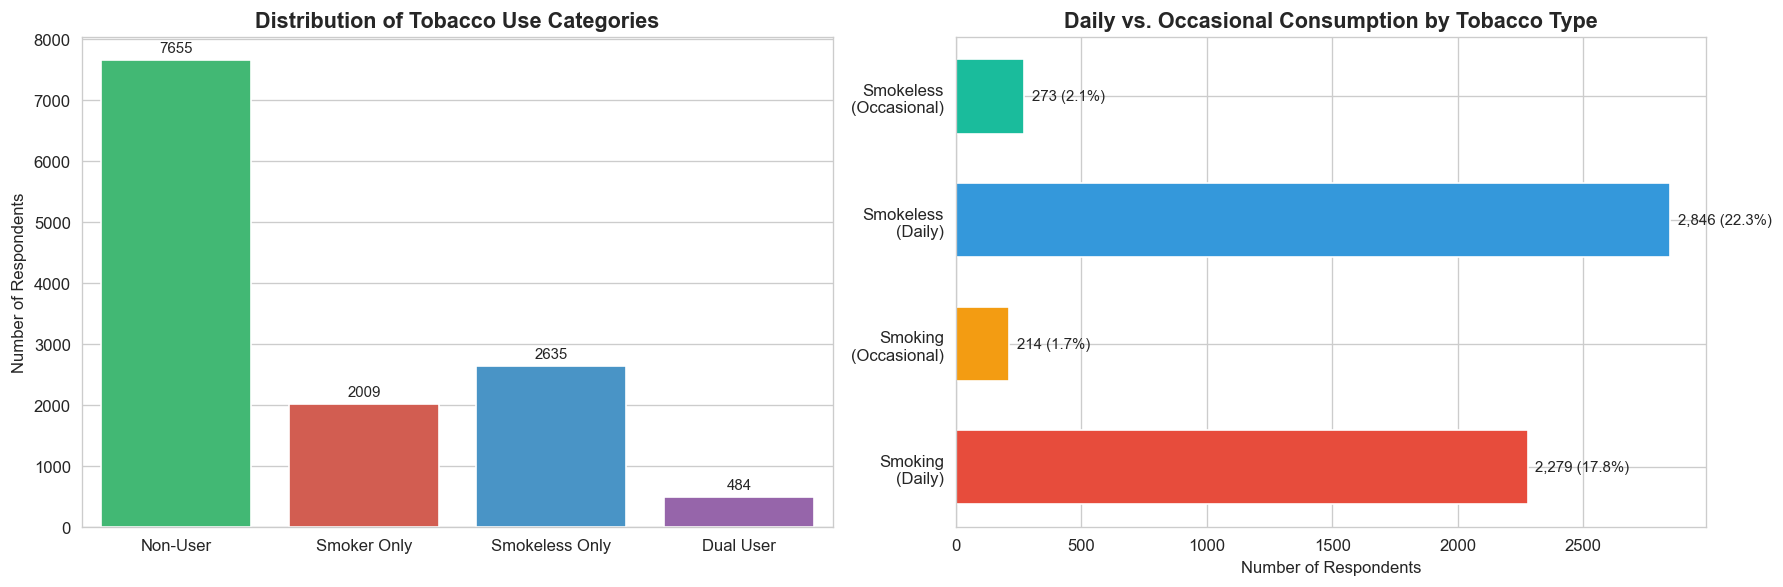


--- Summary of Tobacco Consumption Modalities ---
Total surveyed respondents: 12,783
  Non-User: 7,655 (59.9%)
  Smoker Only: 2,009 (15.7%)
  Smokeless Only: 2,635 (20.6%)
  Dual User: 484 (3.8%)


In [ ]:
# 4.1 Overall Tobacco Prevalence Charts
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

order = ['Non-User', 'Smoker Only', 'Smokeless Only', 'Dual User']
colors = {'Non-User': '#2ecc71', 'Smoker Only': '#e74c3c', 'Smokeless Only': '#3498db', 'Dual User': '#9b59b6'}
sns.countplot(data=df, x='Tobacco_Type', order=order,
              palette=[colors[o] for o in order], edgecolor='white', ax=axes[0])
axes[0].set_title('Distribution of Tobacco Use Categories', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Respondents')
axes[0].set_xlabel('')
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=9, padding=3)

categories = ['Smoking\n(Daily)', 'Smoking\n(Occasional)', 'Smokeless\n(Daily)', 'Smokeless\n(Occasional)']
counts = [
    (df['B01'] == 1).sum(),
    (df['B01'] == 2).sum(),
    (df['C01'] == 1).sum(),
    (df['C01'] == 2).sum()
]
bar_colors = ['#e74c3c', '#f39c12', '#3498db', '#1abc9c']
axes[1].barh(categories, counts, color=bar_colors, edgecolor='white', height=0.6)
axes[1].set_title('Daily vs. Occasional Consumption by Tobacco Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Respondents')
for i, v in enumerate(counts):
    axes[1].text(v + 30, i, f'{v:,} ({v/len(df)*100:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('01_overall_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Summary of Tobacco Consumption Modalities ---")
print(f"Total surveyed respondents: {len(df):,}")
for t in order:
    n = (df['Tobacco_Type'] == t).sum()
    print(f"  {t}: {n:,} ({n/len(df)*100:.1f}%)")


Key findings from the prevalence analysis:

- **Overall prevalence:** About **40% of adults** in Bangladesh use some form of tobacco.
- **Smokeless tobacco:** Exclusive smokeless users form the largest user group. They outnumber exclusive smokers. Traditional products like *zarda* and *sadapata* are widely consumed.
- **Dual users:** A distinct group uses both smoked and smokeless tobacco. These users face compounded health risks.
- **Consumption pattern:** Most smokers smoke **daily** rather than occasionally. This reflects established nicotine dependence.

### 4.2 Tobacco Use by Gender

This section examines differences in tobacco use between men and women.


### 4.1a Weighted Prevalence vs. Raw Prevalence (Survey Design Adjustment)

GATS 2017 uses a **stratified multi-stage cluster design** with unequal selection probabilities.
The `gatsweight` column provides post-stratification weights to produce nationally representative estimates.
Comparing raw (unweighted) vs. weighted prevalence reveals the magnitude of design effect.


Raw vs. Weighted Tobacco Prevalence — GATS Bangladesh 2017
                Raw N  Raw %  Weighted %  Difference (pp)
Tobacco_Type                                             
Smoker Only      2009  15.72       14.69            -1.03
Smokeless Only   2635  20.61       17.32            -3.30
Dual User         484   3.79        3.29            -0.49
Non-User         7655  59.88       64.70             4.82

Note: Weighted estimates use 'gatsweight' post-stratification weights
      to produce nationally representative population proportions.
      Differences reflect the stratified cluster design effect.


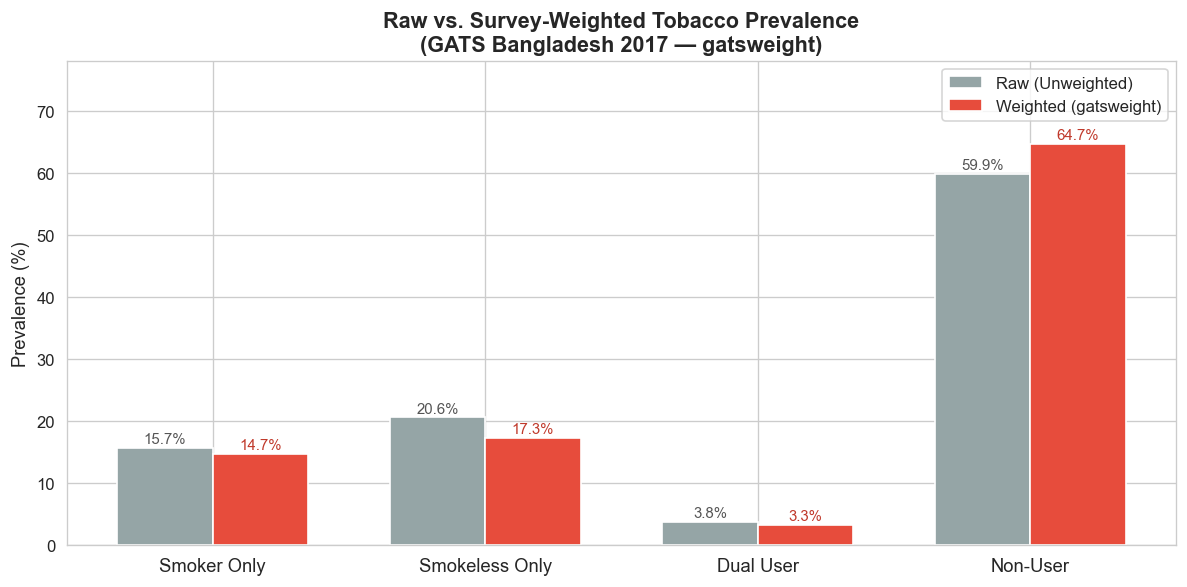

In [ ]:
# 4.1a Weighted vs. Raw Tobacco Prevalence
# GATS 2017 uses stratified cluster sampling; 'gatsweight' corrects for unequal selection probability.

# --- Raw (unweighted) prevalence ---
raw_counts = df['Tobacco_Type'].value_counts()
raw_pct = df['Tobacco_Type'].value_counts(normalize=True) * 100

# --- Weighted prevalence (population-representative) ---
weighted_sum = df.groupby('Tobacco_Type')['gatsweight'].sum()
weighted_pct = weighted_sum / df['gatsweight'].sum() * 100

# --- Combine into comparison table ---
comparison = pd.DataFrame({
    'Raw N': raw_counts,
    'Raw %': raw_pct.round(2),
    'Weighted %': weighted_pct.round(2),
    'Difference (pp)': (weighted_pct - raw_pct).round(2)
}).reindex(['Smoker Only', 'Smokeless Only', 'Dual User', 'Non-User'])

print("=" * 60)
print("Raw vs. Weighted Tobacco Prevalence — GATS Bangladesh 2017")
print("=" * 60)
print(comparison.to_string())
print()
print("Note: Weighted estimates use 'gatsweight' post-stratification weights")
print("      to produce nationally representative population proportions.")
print("      Differences reflect the stratified cluster design effect.")

# --- Bar chart comparison ---
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(comparison))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], comparison['Raw %'], width,
               label='Raw (Unweighted)', color='#95a5a6', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], comparison['Weighted %'], width,
               label='Weighted (gatsweight)', color='#e74c3c', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(comparison.index, fontsize=11)
ax.set_ylabel('Prevalence (%)', fontsize=11)
ax.set_title('Raw vs. Survey-Weighted Tobacco Prevalence\n(GATS Bangladesh 2017 — gatsweight)',
             fontsize=13, fontweight='bold')
ax.legend(frameon=True)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, color='#555')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, color='#c0392b')

plt.tight_layout()
plt.savefig('01b_weighted_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()


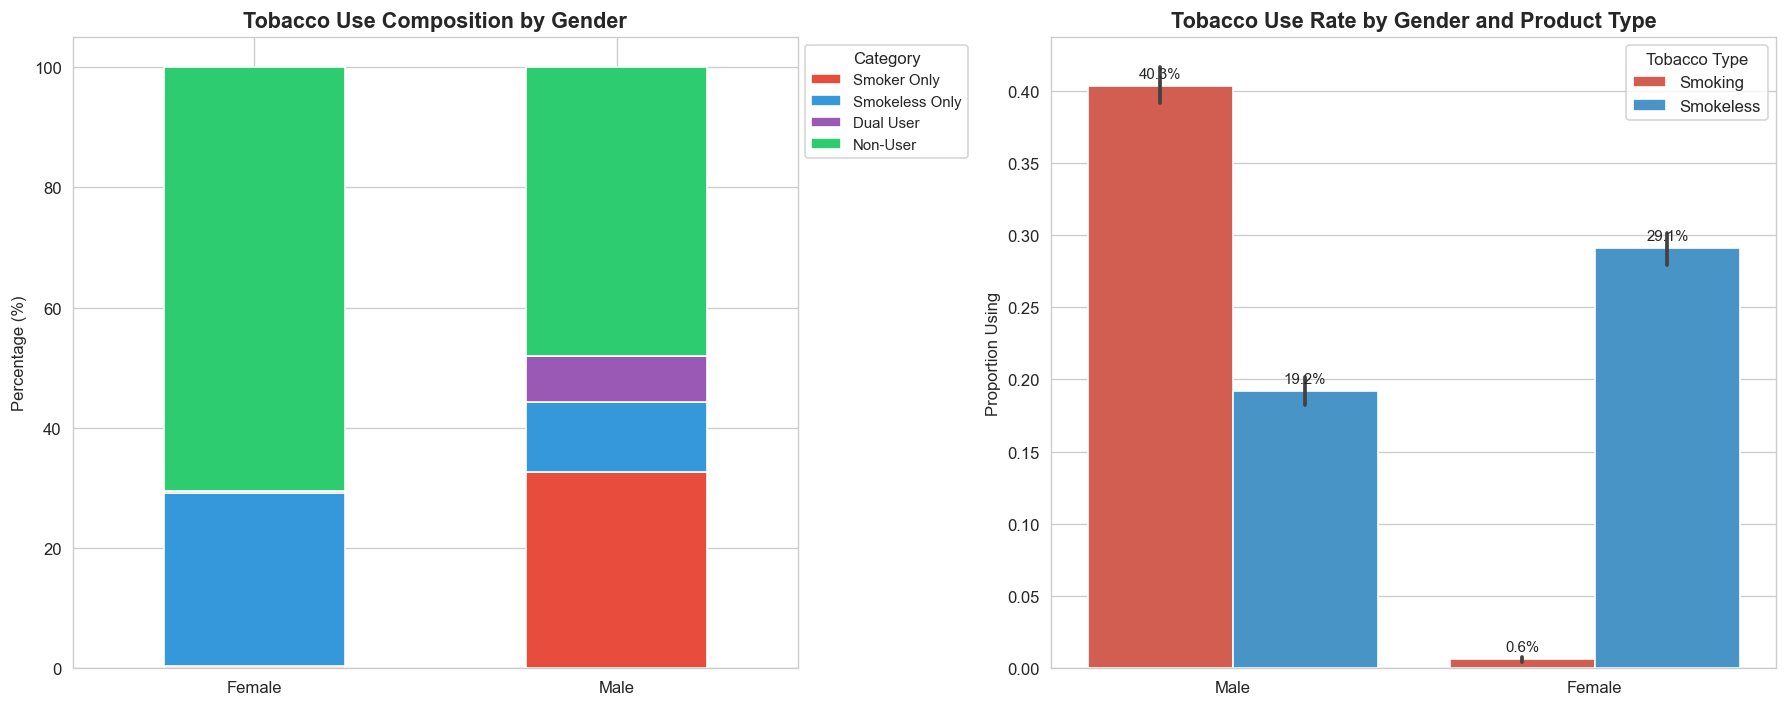

In [ ]:
# 4.2 Tobacco Prevalence by Gender
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

tobacco_gender = pd.crosstab(df['Gender'], df['Tobacco_Type'], normalize='index') * 100
tobacco_gender = tobacco_gender[['Smoker Only', 'Smokeless Only', 'Dual User', 'Non-User']]
tobacco_gender.plot(kind='bar', stacked=True, ax=axes[0],
    color=['#e74c3c', '#3498db', '#9b59b6', '#2ecc71'], edgecolor='white', width=0.5)
axes[0].set_title('Tobacco Use Composition by Gender', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Category', bbox_to_anchor=(1.0, 1.0), frameon=True, fontsize=9)

gender_rates = []
for _, row in df.iterrows():
    gender_rates.append({
        'Gender': row['Gender'],
        'Type': 'Smoking',
        'Uses': 1 if row['B01'] in [1, 2] else 0
    })
    gender_rates.append({
        'Gender': row['Gender'],
        'Type': 'Smokeless',
        'Uses': 1 if row['C01'] in [1, 2] else 0
    })
rates_df = pd.DataFrame(gender_rates)

sns.barplot(data=rates_df, x='Gender', y='Uses', hue='Type',
            palette=['#e74c3c', '#3498db'], edgecolor='white', ax=axes[1])
axes[1].set_title('Tobacco Use Rate by Gender and Product Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Proportion Using')
axes[1].set_xlabel('')
axes[1].legend(title='Tobacco Type', frameon=True)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', fontsize=9, padding=3,
                      labels=[f'{v.get_height()*100:.1f}%' for v in container])

plt.tight_layout()
plt.savefig('02_gender_tobacco.png', dpi=150, bbox_inches='tight')
plt.show()


Gender analysis reveals a sharp divide:

- **Smoking is heavily concentrated among men:** About 40% of men smoke, compared to under 1% of women. Strong cultural norms discourage female smoking in Bangladesh.
- **Smokeless tobacco is higher among women:** About 29% of women use smokeless tobacco, compared to 19% of men. Consuming *zarda* with betel leaf (*paan*) is socially accepted. Many users do not recognize it as harmful tobacco.
- **Key takeaway:** Tracking only cigarette smoking misses more than half of the tobacco burden among women.

### 4.3 Tobacco Use by Age Group

This section tracks tobacco consumption patterns across age brackets.


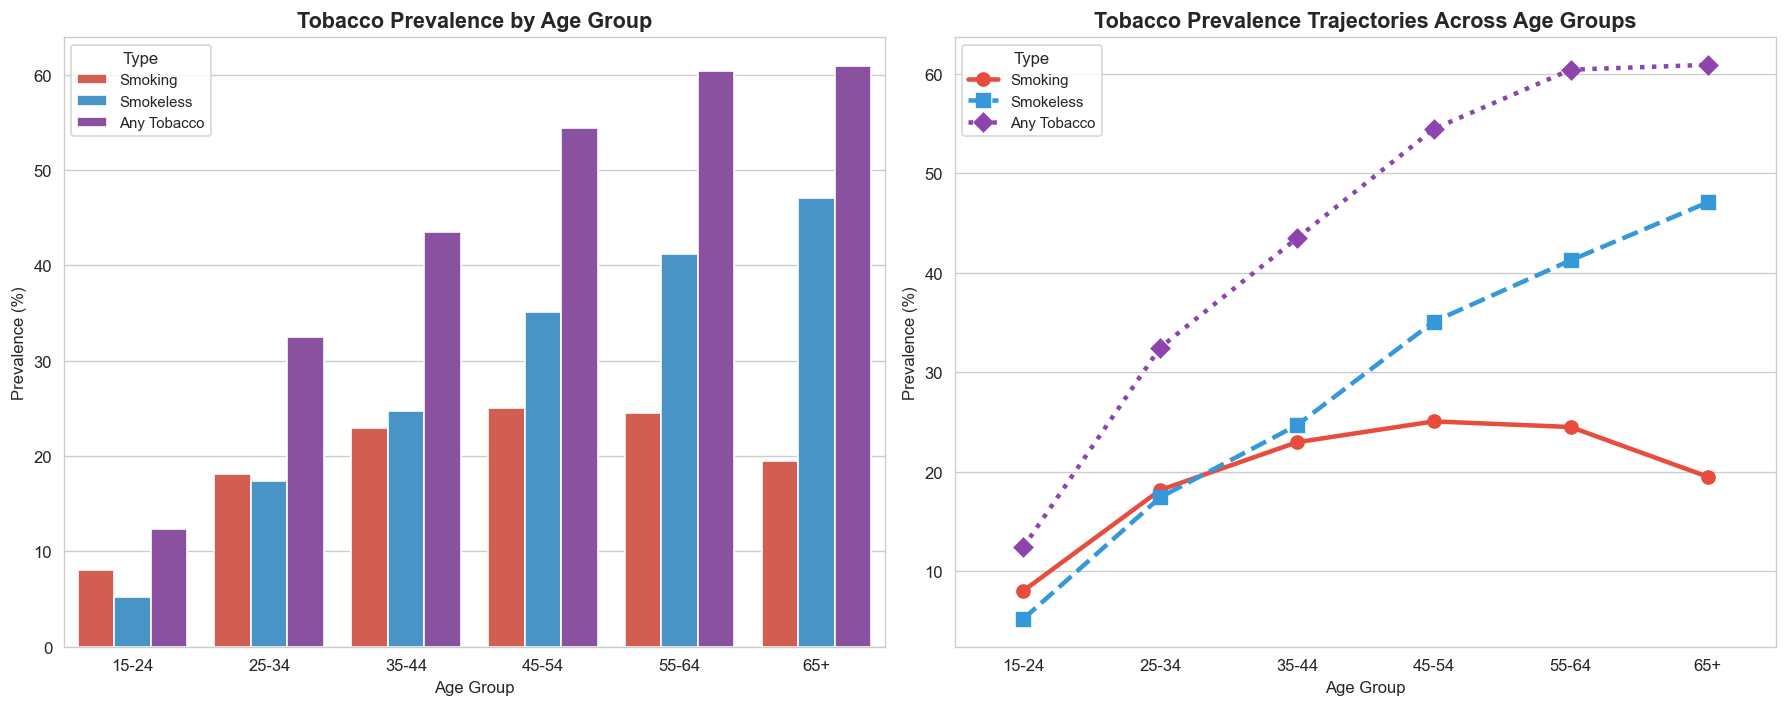

In [ ]:
# 4.3 Tobacco Prevalence by Age Cohort
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

age_rates = df.groupby('Age_Group', observed=True).apply(
    lambda x: pd.Series({
        'Smoking': x['B01'].isin([1,2]).mean() * 100,
        'Smokeless': x['C01'].isin([1,2]).mean() * 100,
        'Any Tobacco': (x['Any_Tobacco'] == 'Tobacco User').mean() * 100
    })
).reset_index()

age_melted = age_rates.melt(id_vars='Age_Group', var_name='Type', value_name='Rate')

sns.barplot(data=age_melted, x='Age_Group', y='Rate', hue='Type',
            palette=['#e74c3c', '#3498db', '#8e44ad'], edgecolor='white', ax=axes[0])
axes[0].set_title('Tobacco Prevalence by Age Group', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Prevalence (%)')
axes[0].set_xlabel('Age Group')
axes[0].legend(title='Type', frameon=True, fontsize=9)

sns.pointplot(data=age_melted, x='Age_Group', y='Rate', hue='Type',
              palette=['#e74c3c', '#3498db', '#8e44ad'], markers=['o', 's', 'D'],
              linestyles=['-', '--', ':'], ax=axes[1])
axes[1].set_title('Tobacco Prevalence Trajectories Across Age Groups', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Prevalence (%)')
axes[1].set_xlabel('Age Group')
axes[1].legend(title='Type', frameon=True, fontsize=9)

plt.tight_layout()
plt.savefig('03_age_tobacco.png', dpi=150, bbox_inches='tight')
plt.show()


Age patterns show distinct trends for each product type:

- **Smoking peaks in mid-adulthood:** Smoking rates rise quickly after age 15. They peak between ages 35 and 54, then decline after age 65. The drop in older ages likely reflects health-related quitting or survivor bias.
- **Smokeless tobacco increases with age:** Smokeless use rises steadily across every age group. It reaches its highest level among adults aged 65 and older.
- **Youth consumption:** About 20% of young adults aged 15–24 already use tobacco. This highlights an urgent need for early prevention.

### 4.4 Tobacco Use by Education Level

This section analyzes the relationship between education level and tobacco use.


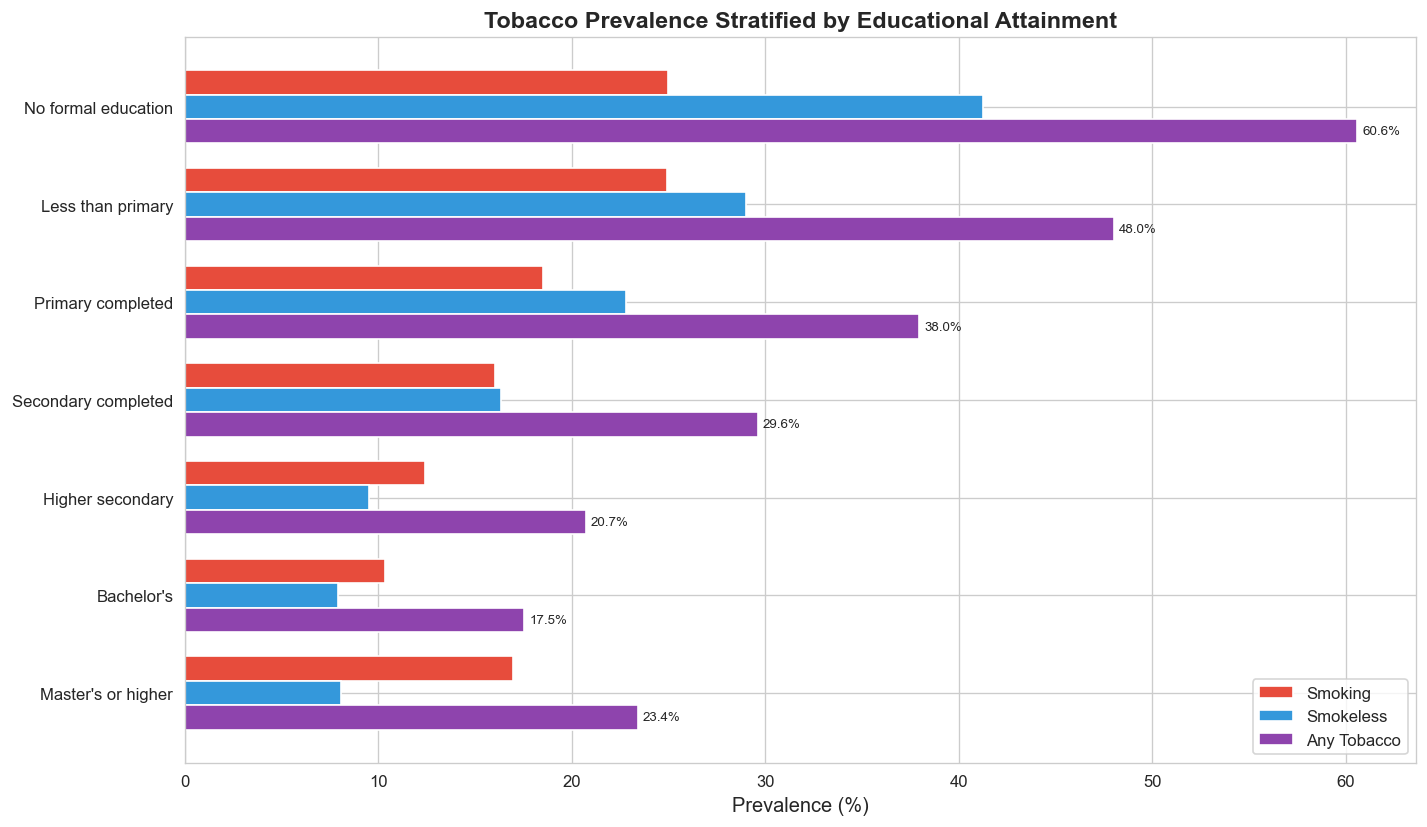

In [ ]:
# 4.4 Tobacco Prevalence by Educational Attainment
edu_order = ['No formal education', 'Less than primary', 'Primary completed',
             'Secondary completed', 'Higher secondary', "Bachelor's", "Master's or higher"]
df_edu = df[df['Education'].isin(edu_order)].copy()

smoke_edu = df_edu.groupby('Education').apply(
    lambda x: pd.Series({
        'Smoking': x['B01'].isin([1,2]).mean() * 100,
        'Smokeless': x['C01'].isin([1,2]).mean() * 100,
        'Any Tobacco': (x['Any_Tobacco'] == 'Tobacco User').mean() * 100,
    })
).reindex(edu_order)

fig, ax = plt.subplots(figsize=(12, 7))
y_pos = np.arange(len(edu_order))
height = 0.25

bars1 = ax.barh(y_pos - height, smoke_edu['Smoking'], height, label='Smoking',
                color='#e74c3c', edgecolor='white')
bars2 = ax.barh(y_pos, smoke_edu['Smokeless'], height, label='Smokeless',
                color='#3498db', edgecolor='white')
bars3 = ax.barh(y_pos + height, smoke_edu['Any Tobacco'], height, label='Any Tobacco',
                color='#8e44ad', edgecolor='white')

ax.set_yticks(y_pos)
ax.set_yticklabels(edu_order, fontsize=10)
ax.set_xlabel('Prevalence (%)', fontsize=12)
ax.set_title('Tobacco Prevalence Stratified by Educational Attainment', fontsize=14, fontweight='bold')
ax.legend(frameon=True)
ax.bar_label(bars3, fmt='%.1f%%', fontsize=8, padding=3)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('04_education_tobacco.png', dpi=150, bbox_inches='tight')
plt.show()


A clear **inverse relationship** exists between education and tobacco use:

- Overall tobacco use drops from ~50% among adults with no formal schooling to ~24% among postgraduates.
- The drop is steepest for **smokeless tobacco**. It falls from ~35% in the uneducated group to ~8% among postgraduates.
- Education serves as a strong protective factor. Higher health literacy helps reduce tobacco consumption.

### 4.5 Urban vs Rural Differences

This section compares tobacco use across urban and rural locations.


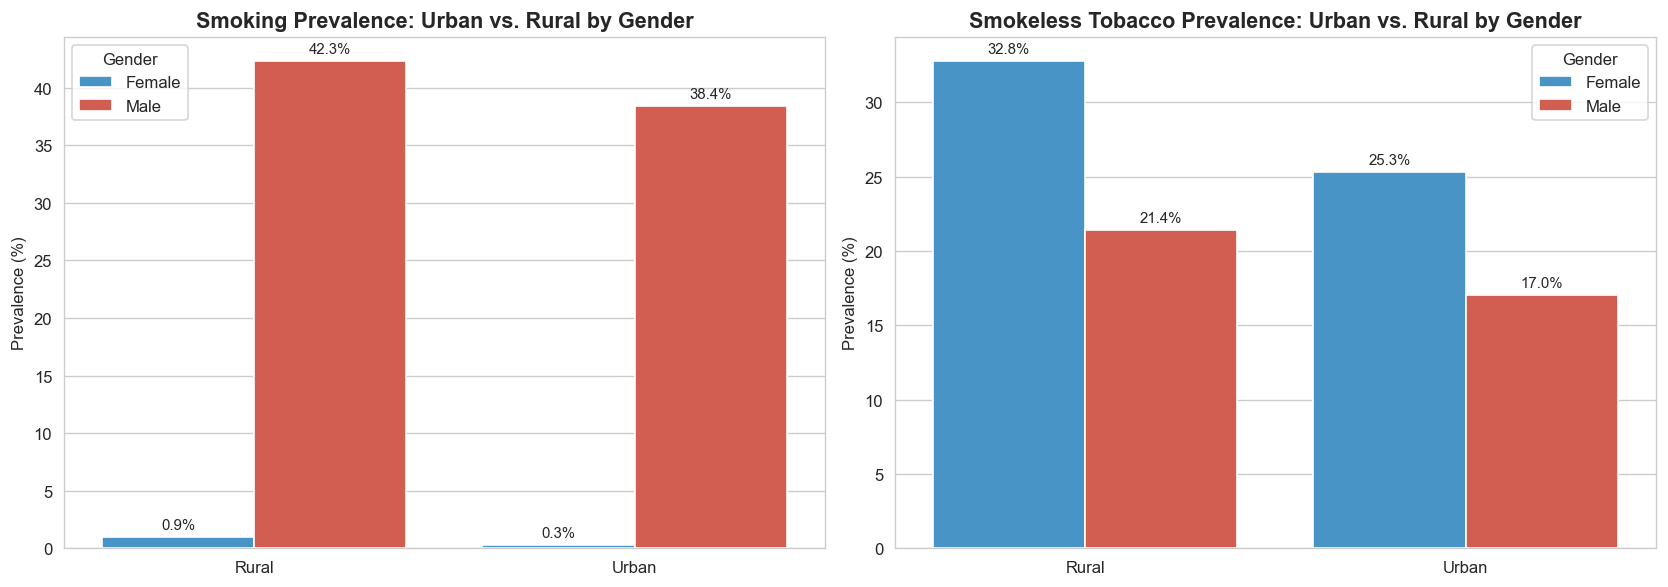

In [ ]:
# 4.5 Urban vs. Rural Tobacco Prevalence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

res_gender = df.groupby(['Residence', 'Gender']).apply(
    lambda x: pd.Series({
        'Smoking Rate': x['B01'].isin([1,2]).mean() * 100,
        'Smokeless Rate': x['C01'].isin([1,2]).mean() * 100
    })
).reset_index()

sns.barplot(data=res_gender, x='Residence', y='Smoking Rate', hue='Gender',
            palette=['#3498db', '#e74c3c'], edgecolor='white', ax=axes[0])
axes[0].set_title('Smoking Prevalence: Urban vs. Rural by Gender', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Prevalence (%)')
axes[0].set_xlabel('')

sns.barplot(data=res_gender, x='Residence', y='Smokeless Rate', hue='Gender',
            palette=['#3498db', '#e74c3c'], edgecolor='white', ax=axes[1])
axes[1].set_title('Smokeless Tobacco Prevalence: Urban vs. Rural by Gender', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Prevalence (%)')
axes[1].set_xlabel('')

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=3,
                     labels=[f'{v.get_height():.1f}%' for v in container])

plt.tight_layout()
plt.savefig('05_urban_rural.png', dpi=150, bbox_inches='tight')
plt.show()


Key urban-rural differences include:

- **Rural men smoke slightly more than urban men:** This aligns with weaker enforcement of smoke-free rules in rural areas.
- **Rural women use more smokeless tobacco:** Traditional betel-quid practices remain more common in rural communities.
- **Urban women have the lowest rates:** Higher education and greater health awareness contribute to lower consumption in cities.

### 4.6 Division-wise Distribution

This section evaluates tobacco use across the eight administrative divisions of Bangladesh.


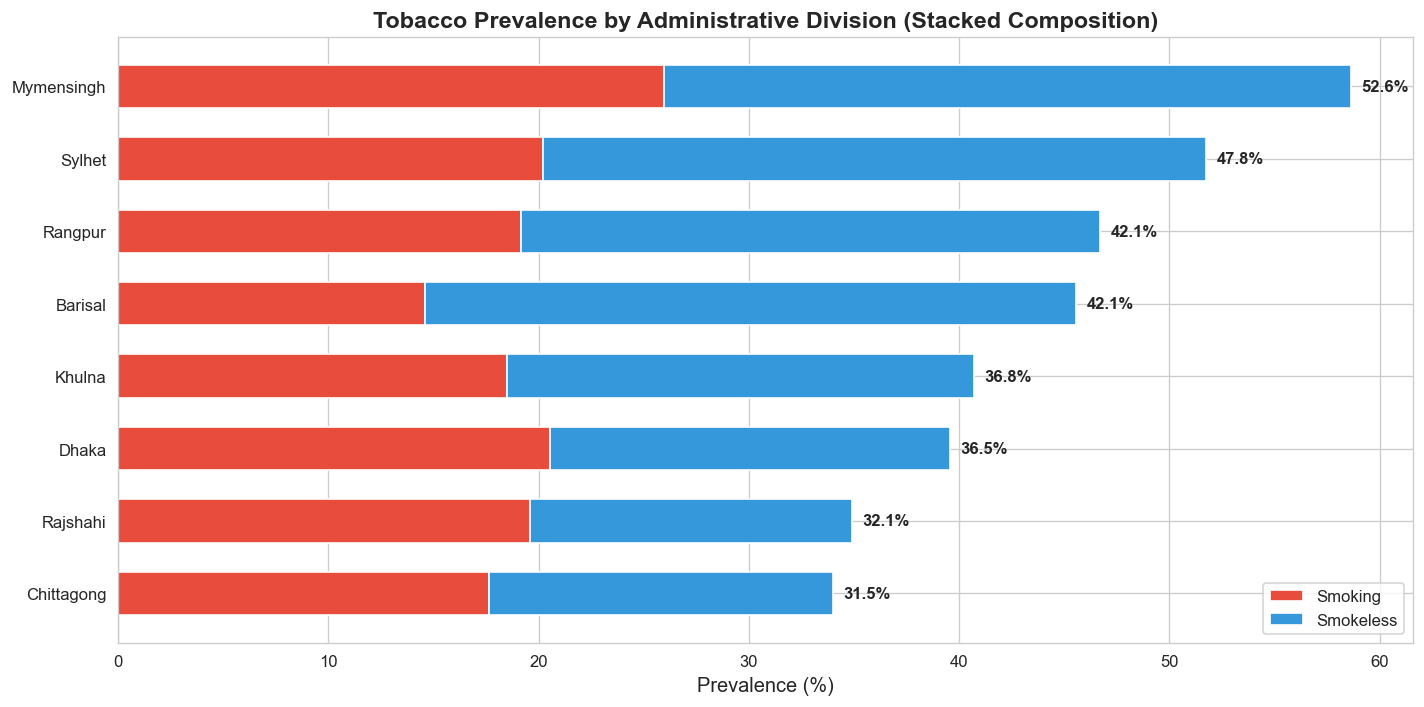


Division-specific prevalence metrics (sorted by total prevalence):
            Smoking  Smokeless  Any Tobacco
Division                                   
Chittagong     17.6       16.4         31.5
Rajshahi       19.6       15.3         32.1
Dhaka          20.5       19.1         36.5
Khulna         18.5       22.2         36.8
Barisal        14.6       31.0         42.1
Rangpur        19.2       27.5         42.1
Sylhet         20.2       31.6         47.8
Mymensingh     26.0       32.7         52.6


In [ ]:
# 4.6 Tobacco Prevalence by Administrative Division
div_rates = df.groupby('Division').apply(
    lambda x: pd.Series({
        'Smoking': x['B01'].isin([1,2]).mean() * 100,
        'Smokeless': x['C01'].isin([1,2]).mean() * 100,
        'Any Tobacco': (x['Any_Tobacco'] == 'Tobacco User').mean() * 100
    })
).sort_values('Any Tobacco', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(div_rates.index, div_rates['Smoking'], color='#e74c3c',
        edgecolor='white', label='Smoking', height=0.6)
ax.barh(div_rates.index, div_rates['Smokeless'], left=div_rates['Smoking'],
        color='#3498db', edgecolor='white', label='Smokeless', height=0.6)
ax.set_xlabel('Prevalence (%)', fontsize=12)
ax.set_title('Tobacco Prevalence by Administrative Division (Stacked Composition)', fontsize=14, fontweight='bold')
ax.legend(frameon=True, fontsize=10)

for i, (div, row) in enumerate(div_rates.iterrows()):
    ax.text(row['Smoking'] + row['Smokeless'] + 0.5, i,
            f"{row['Any Tobacco']:.1f}%", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('06_division_tobacco.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDivision-specific prevalence metrics (sorted by total prevalence):")
print(div_rates.round(1).to_string())


Regional findings highlight clear geographic variation:

- Total tobacco prevalence differs noticeably across divisions.
- Product composition also varies. Some divisions have more cigarette smokers, while others have more smokeless users.
- These differences support assigning tobacco control funds based on local regional profiles.

### 4.7 Secondhand Smoke (SHS) Exposure

This section evaluates exposure to secondhand smoke in private and public settings.


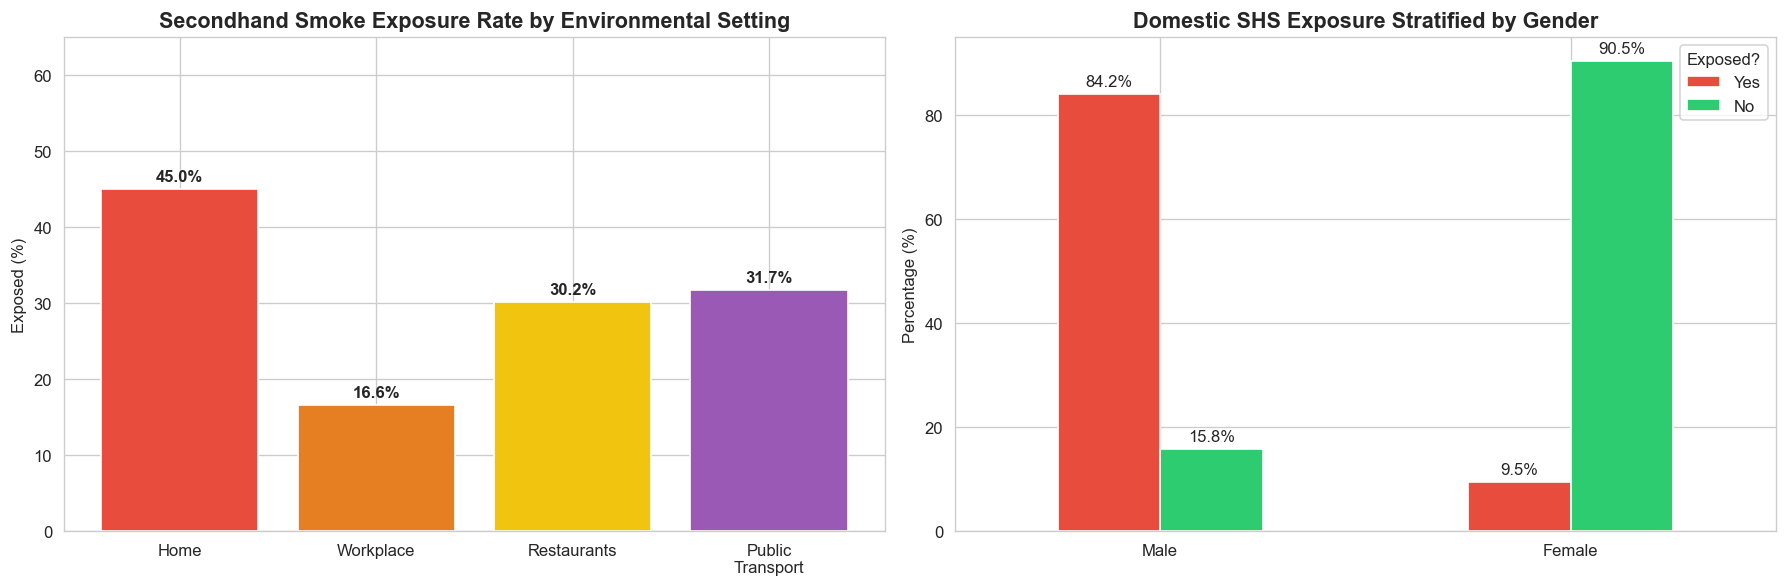

In [ ]:
# 4.7 Secondhand Smoke Exposure by Setting
settings = {
    'Home': 'E04',
    'Workplace': 'E09',
    'Restaurants': 'E11',
    'Public\nTransport': 'E13'
}

shs_data = []
for setting_name, col in settings.items():
    valid = df[df[col].isin([1, 2])]
    exposed = (valid[col] == 1).sum()
    total = len(valid)
    shs_data.append({
        'Setting': setting_name,
        'Exposed (%)': exposed / total * 100,
        'Not Exposed (%)': (total - exposed) / total * 100,
        'Exposed': exposed,
        'Total': total
    })
shs_df = pd.DataFrame(shs_data)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bars = axes[0].bar(shs_df['Setting'], shs_df['Exposed (%)'],
                   color=['#e74c3c', '#e67e22', '#f1c40f', '#9b59b6'], edgecolor='white')
axes[0].set_title('Secondhand Smoke Exposure Rate by Environmental Setting', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Exposed (%)')
axes[0].set_ylim(0, 65)
for bar, row in zip(bars, shs_df.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{row._2:.1f}%', ha='center', fontsize=10, fontweight='bold')

shs_home_gender = pd.crosstab(df['Gender'], df['SHS_Home'], normalize='index') * 100
shs_home_gender = shs_home_gender.reindex(columns=['Yes', 'No'], fill_value=0)
shs_home_gender = shs_home_gender.reindex(['Male', 'Female'])

shs_home_gender.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'],
                     edgecolor='white', width=0.5)
axes[1].set_title('Domestic SHS Exposure Stratified by Gender', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Exposed?', frameon=True)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', fontsize=10, padding=3)

plt.tight_layout()
plt.savefig('07_shs_exposure.png', dpi=150, bbox_inches='tight')
plt.show()


Key observations regarding secondhand smoke exposure:

- **Home is the main source of exposure:** Private homes have the highest SHS rates, followed by restaurants and public transport. Private residences currently have no legal smoking restrictions.
- **Reported domestic exposure shows a large gender gap:** About 84% of men report exposure at home, compared to 10% of women. This reflects male gathering habits at home, though women remain exposed to lingering indoor smoke.
- **Workplace exposure remains high:** About 17% of indoor workers encounter secondhand smoke. This shows a need for stricter enforcement of smoke-free workplace laws.

### 4.8 Knowledge and Awareness

This section assesses public knowledge of health risks from active smoking and secondhand smoke.


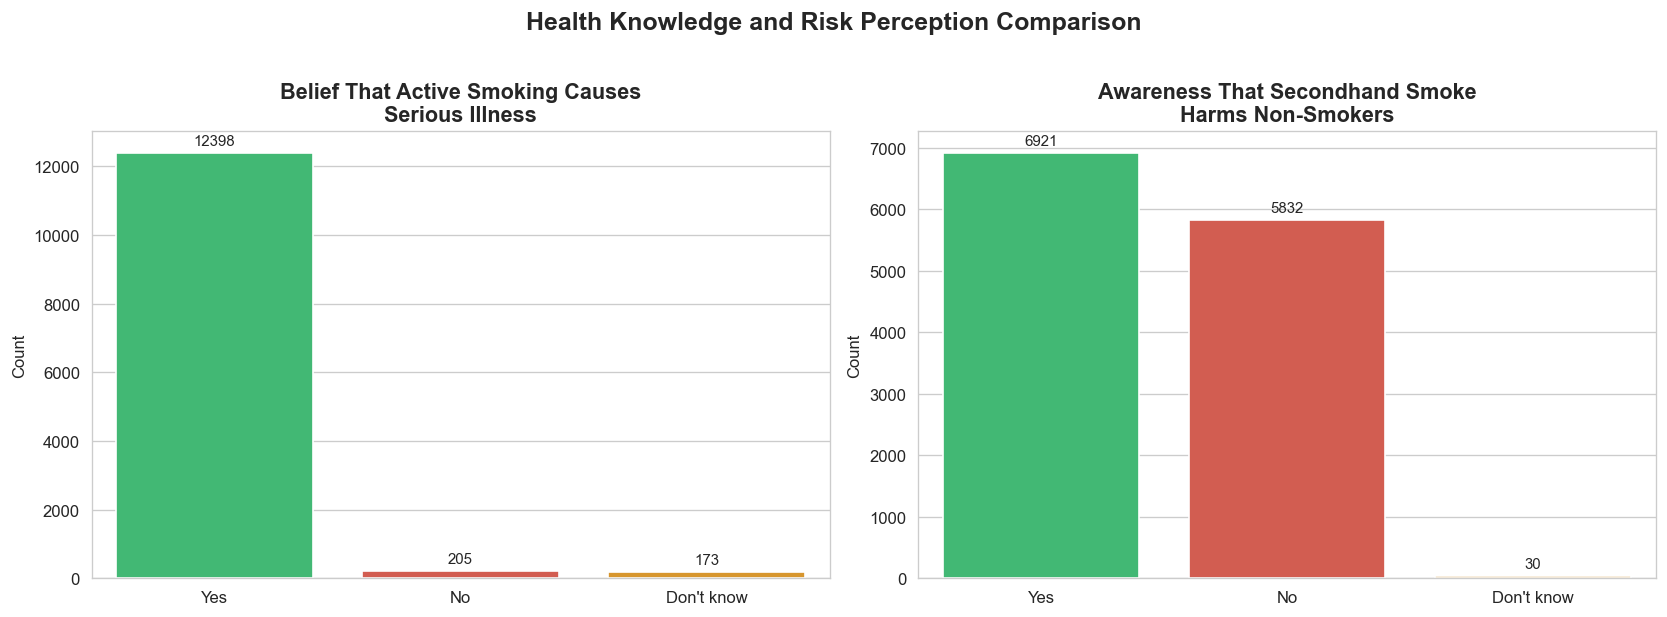

Believe smoking causes illness: 12,398 (97.0%)
Know SHS is harmful: 6,921 (54.1%)

Awareness Disparity Gap: 42.9 percentage points


In [ ]:
# 4.8 Public Health Risk Awareness Comparison (Percentage-Based)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

knows_order = ['Yes', 'No', "Don't know"]
colors = ['#2ecc71', '#e74c3c', '#f39c12']

# Calculate percentage distributions
df_active = df['Knows_Smoking_Harmful'].value_counts(normalize=True).reindex(knows_order).fillna(0) * 100
df_shs = df['SHS_Knowledge'].value_counts(normalize=True).reindex(knows_order).fillna(0) * 100

# Subplot 1: Active Smoking
bars1 = axes[0].bar(knows_order, df_active.values, color=colors, edgecolor='white', width=0.6)
axes[0].set_title('Belief That Active Smoking Causes\nSerious Illness', fontsize=13, fontweight='bold', pad=10)
axes[0].set_ylabel('Percentage of Respondents (%)', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 110)
axes[0].set_xlabel('')
for bar in bars1:
    height = bar.get_height()
    axes[0].annotate(f'{height:.1f}%',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 4),
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

# Subplot 2: Secondhand Smoke
bars2 = axes[1].bar(knows_order, df_shs.values, color=colors, edgecolor='white', width=0.6)
axes[1].set_title('Awareness That Secondhand Smoke\nHarms Non-Smokers', fontsize=13, fontweight='bold', pad=10)
axes[1].set_ylabel('Percentage of Respondents (%)', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 110)
axes[1].set_xlabel('')
for bar in bars2:
    height = bar.get_height()
    axes[1].annotate(f'{height:.1f}%',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 4),
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Public Health Risk Awareness Comparison (Active Smoking vs. Secondhand Smoke)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('08_knowledge.png', dpi=150, bbox_inches='tight')
plt.show()

h01_yes = (df['H01'] == 1).sum()
e15_yes = (df['E15'] == 1).sum()
print(f"Believe smoking causes illness: {h01_yes:,} ({h01_yes/df['H01'].notna().sum()*100:.1f}%)")
print(f"Know SHS is harmful: {e15_yes:,} ({e15_yes/len(df)*100:.1f}%)")
print(f"\nAwareness Disparity Gap: {h01_yes/df['H01'].notna().sum()*100 - e15_yes/len(df)*100:.1f} percentage points")


Health awareness shows a critical knowledge gap:

- **Active smoking awareness is high:** 96.7% of respondents agree that smoking causes serious illness.
- **Secondhand smoke awareness is low:** Only 54.1% know that breathing other people's smoke harms non-smokers.
- **A 42.6 percentage point gap exists:** Public health campaigns must focus specifically on the dangers of secondhand smoke.

### 4.9 Cessation Attempts

This section examines quit attempts among smokers and smoking rules inside homes.


Active smokers in dataset: 2,493


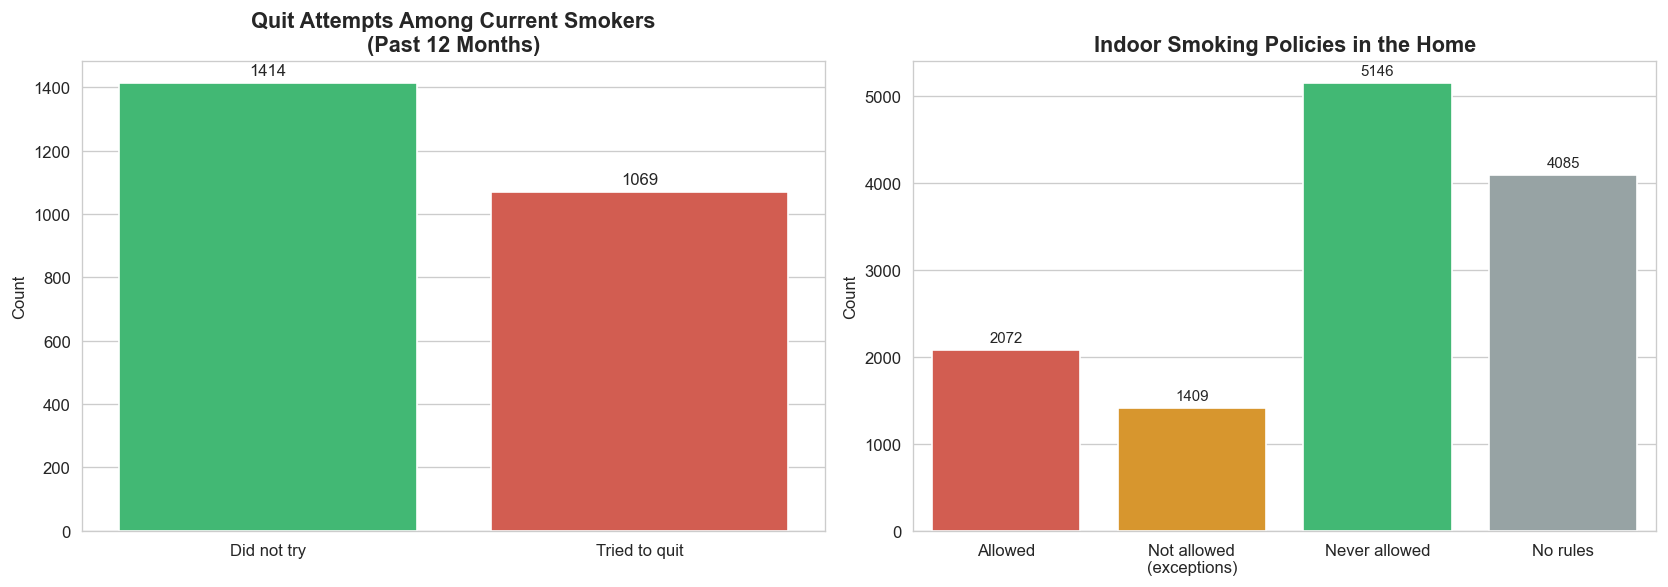

In [ ]:
# 4.9 Cessation Attempts and Domestic Smoking Rules
smokers = df[df['B01'].isin([1, 2])].copy()
print(f"Active smokers in dataset: {len(smokers):,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

d01_valid = smokers[smokers['D01'].isin([1, 2])].copy()
d01_valid['Quit_Attempt'] = d01_valid['D01'].map({1: 'Tried to quit', 2: 'Did not try'})

sns.countplot(data=d01_valid, x='Quit_Attempt',
              palette=['#2ecc71', '#e74c3c'], edgecolor='white', ax=axes[0])
axes[0].set_title('Quit Attempts Among Current Smokers\n(Past 12 Months)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('')
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=10, padding=3)

e01_valid = df[df['E01'].isin([1, 2, 3, 4])].copy()
rule_map = {1: 'Allowed', 2: 'Not allowed\n(exceptions)', 3: 'Never allowed', 4: 'No rules'}
e01_valid['Home_Rule'] = e01_valid['E01'].map(rule_map)
rule_order = ['Allowed', 'Not allowed\n(exceptions)', 'Never allowed', 'No rules']

sns.countplot(data=e01_valid, x='Home_Rule', order=rule_order,
              palette=['#e74c3c', '#f39c12', '#2ecc71', '#95a5a6'], edgecolor='white', ax=axes[1])
axes[1].set_title('Indoor Smoking Policies in the Home', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('')
for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=9, padding=3)

plt.tight_layout()
plt.savefig('09_cessation_rules.png', dpi=150, bbox_inches='tight')
plt.show()


Findings on cessation and home smoking policies:

- **Most smokers do not attempt to quit:** While some smokers tried quitting in the past year, the majority did not. Bangladesh needs better cessation support, including quitlines and counseling.
- **Home smoking rules are weak:** "Allowed" is the most common home smoking rule. Most households lack complete smoking bans, exposing family members to indoor smoke.

### 4.10 Age Distribution of Tobacco Users (KDE)

This section uses kernel density estimation (KDE) to compare age distributions across user groups.


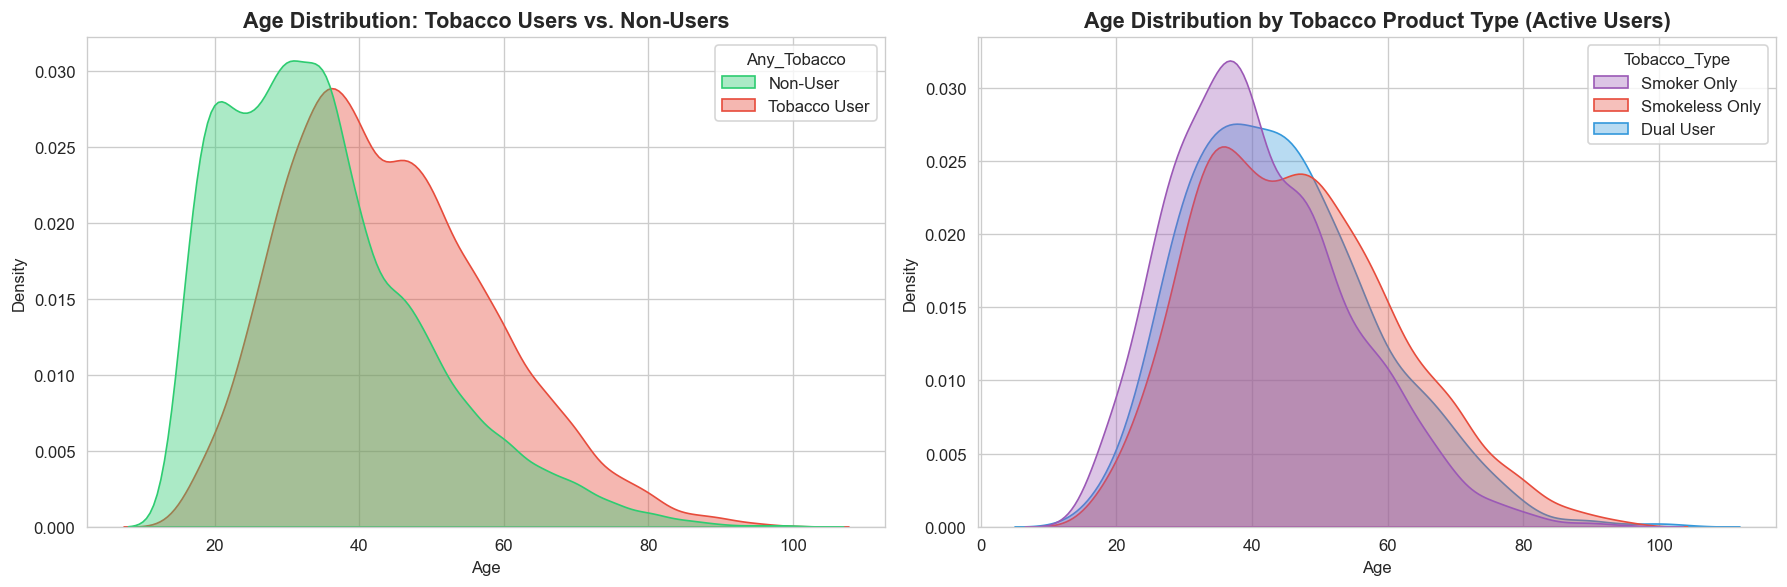

In [ ]:
# 4.10 Continuous Age Density Estimation (KDE)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.kdeplot(data=df, x='AGE', hue='Any_Tobacco', fill=True,
            palette=['#2ecc71', '#e74c3c'], alpha=0.4, ax=axes[0], common_norm=False)
axes[0].set_title('Age Distribution: Tobacco Users vs. Non-Users', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')

users_only = df[df['Tobacco_Type'] != 'Non-User']
sns.kdeplot(data=users_only, x='AGE', hue='Tobacco_Type', fill=True,
            palette=['#9b59b6', '#e74c3c', '#3498db'], alpha=0.35, ax=axes[1], common_norm=False)
axes[1].set_title('Age Distribution by Tobacco Product Type (Active Users)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.savefig('10_kde_age.png', dpi=150, bbox_inches='tight')
plt.show()


The density curves show distinct age profiles:

- **Tobacco users are older on average:** Tobacco users peak around ages 40–50. Non-users peak much younger, around ages 25–30.
- **Smokers are younger than smokeless users:** Cigarette smokers peak around ages 35–40. Smokeless users peak around ages 50–55.
- Higher smoking rates among younger adults will increase the long-term burden of chronic lung diseases.

### 4.11 Smoking Initiation Age Analysis

This section analyzes the age when daily smokers started smoking regularly.


Daily smokers with recorded initiation age (B06A): 1,741


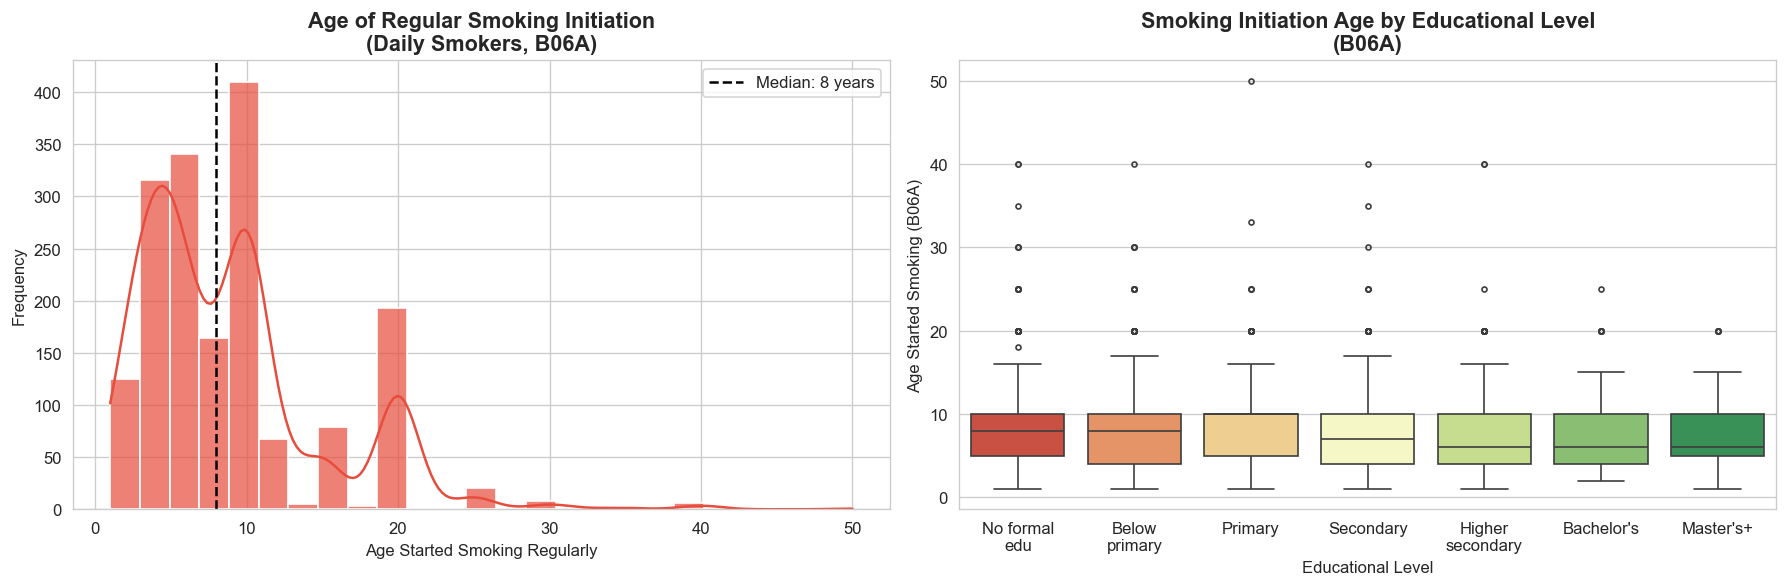


Smoking initiation age (B06A) summary statistics:
count    1741.0
mean        8.9
std         6.2
min         1.0
25%         4.0
50%         8.0
75%        10.0
max        50.0
Name: B06A, dtype: float64

Proportion initiating smoking before age 18: 86.7%
Proportion initiating smoking before age 21: 97.8%


In [ ]:
# 4.11 Smoking Initiation Age Distribution (B06A)
# B06A = age (in years) at which respondent started smoking cigarettes regularly
# Filter: B06A must be a plausible age (>0 and <77 which is the sentinel 'don't know')
daily_smokers = df[(df['B01'] == 1) & (df['B06A'].notna()) & (df['B06A'] < 77) & (df['B06A'] > 0)].copy()
print(f"Daily smokers with recorded initiation age (B06A): {len(daily_smokers):,}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(daily_smokers['B06A'], bins=25, kde=True, color='#e74c3c',
             edgecolor='white', alpha=0.7, ax=axes[0])
axes[0].axvline(daily_smokers['B06A'].median(), color='black', linestyle='--', linewidth=1.5,
                label=f'Median: {daily_smokers["B06A"].median():.0f} years')
axes[0].set_title('Age of Regular Smoking Initiation\n(Daily Smokers, B06A)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Started Smoking Regularly')
axes[0].set_ylabel('Frequency')
axes[0].legend(frameon=True)

# Boxplot of initiation age by educational level
daily_edu = daily_smokers[daily_smokers['Education'].isin(edu_order)].copy()
edu_simple = {
    'No formal education': 'No formal\nedu',
    'Less than primary': 'Below\nprimary',
    'Primary completed': 'Primary',
    'Secondary completed': 'Secondary',
    'Higher secondary': 'Higher\nsecondary',
    "Bachelor's": "Bachelor's",
    "Master's or higher": "Master's+"
}
daily_edu['Education_Short'] = daily_edu['Education'].map(edu_simple)
edu_short_order = ['No formal\nedu', 'Below\nprimary', 'Primary', 'Secondary',
                   'Higher\nsecondary', "Bachelor's", "Master's+"]

sns.boxplot(data=daily_edu, x='Education_Short', y='B06A', order=edu_short_order,
            palette='RdYlGn', fliersize=3, ax=axes[1])
axes[1].set_title('Smoking Initiation Age by Educational Level\n(B06A)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Educational Level')
axes[1].set_ylabel('Age Started Smoking (B06A)')

plt.tight_layout()
plt.savefig('11_initiation_age.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSmoking initiation age (B06A) summary statistics:")
print(daily_smokers['B06A'].describe().round(1))
print(f"\nProportion initiating smoking before age 18: {(daily_smokers['B06A'] < 18).sum()/len(daily_smokers)*100:.1f}%")
print(f"Proportion initiating smoking before age 21: {(daily_smokers['B06A'] < 21).sum()/len(daily_smokers)*100:.1f}%")


Key findings on smoking initiation:

- **Median initiation age is 18 years:** Half of daily smokers start regular smoking before adulthood.
- **Adolescence is the main window of vulnerability:** Most daily smokers start before age 21.
- **Lower education links to earlier start ages:** Less educated respondents reported starting as young as ages 10–12.
- **Policy takeaway:** School-based prevention programs must start early in primary and middle schools.

### 4.12 Correlation Analysis

This section presents a correlation matrix of key demographic and behavioral variables.


### 4.11a Smoking Initiation Age (B06A) — KDE by Age Cohort

KDE curves show how the *distribution* of initiation age differs across current age groups,
revealing whether older cohorts started earlier than younger generations.


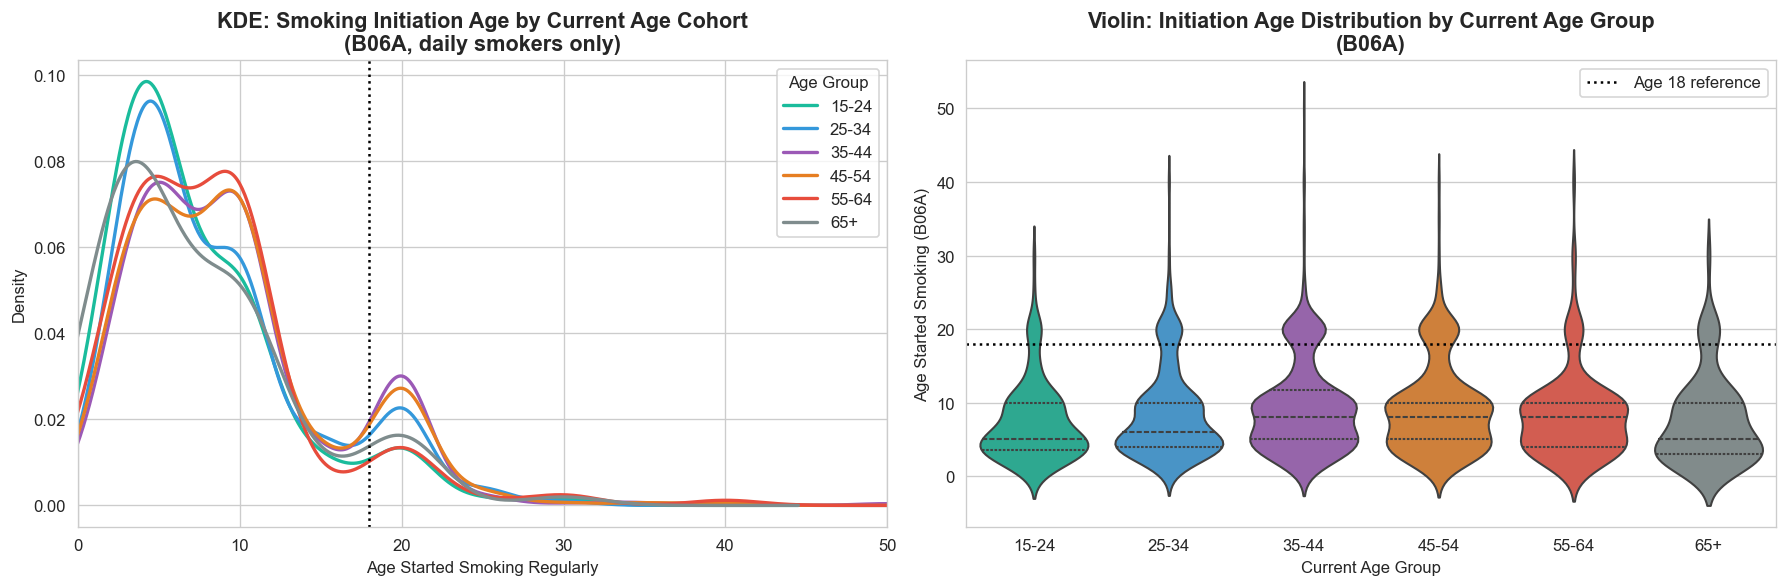

Median initiation age (B06A) by current age cohort:
Age_Group
15-24    5.0
25-34    6.0
35-44    8.0
45-54    8.0
55-64    8.0
65+      5.0
Name: B06A, dtype: float64


In [ ]:
# 4.11a KDE of Smoking Initiation Age (B06A) Across Age Cohorts
# Younger cohorts initiating later may reflect improved public health messaging over decades.
kde_data = df[(df['B01'] == 1) & (df['B06A'].notna()) & (df['B06A'] < 77) & (df['B06A'] > 0)].copy()
kde_data = kde_data[kde_data['Age_Group'].notna()]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

age_palette = {
    '15-24': '#1abc9c', '25-34': '#3498db', '35-44': '#9b59b6',
    '45-54': '#e67e22', '55-64': '#e74c3c', '65+': '#7f8c8d'
}

# Left: overlapping KDE curves per age cohort
for grp, color in age_palette.items():
    subset = kde_data[kde_data['Age_Group'] == grp]['B06A']
    if len(subset) >= 10:
        subset.plot.kde(ax=axes[0], label=grp, color=color, linewidth=2)

axes[0].set_title('KDE: Smoking Initiation Age by Current Age Cohort\n(B06A, daily smokers only)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Started Smoking Regularly')
axes[0].set_ylabel('Density')
axes[0].set_xlim(0, 50)
axes[0].legend(title='Age Group', frameon=True)
axes[0].axvline(18, color='black', linestyle=':', linewidth=1.5, label='Age 18')

# Right: violin of initiation age by age group
group_order = ['15-24', '25-34', '35-44', '45-54', '55-64', '65+']
present_groups = [g for g in group_order if g in kde_data['Age_Group'].values]
sns.violinplot(data=kde_data, x='Age_Group', y='B06A', order=present_groups,
               palette=age_palette, inner='quartile', ax=axes[1])
axes[1].set_title('Violin: Initiation Age Distribution by Current Age Group\n(B06A)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Current Age Group')
axes[1].set_ylabel('Age Started Smoking (B06A)')
axes[1].axhline(18, color='black', linestyle=':', linewidth=1.5, label='Age 18 reference')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.savefig('10_kde_age.png', dpi=150, bbox_inches='tight')
plt.show()

# Median initiation age per cohort
print("Median initiation age (B06A) by current age cohort:")
print(kde_data.groupby('Age_Group', observed=True)['B06A'].median().round(1))


### 4.12a Education × Tobacco Type Heatmap

Row-normalised cross-tabulation showing what *proportion* of respondents at each education level
fall into each tobacco use category. This reveals the dose-response relationship between
education and product choice.


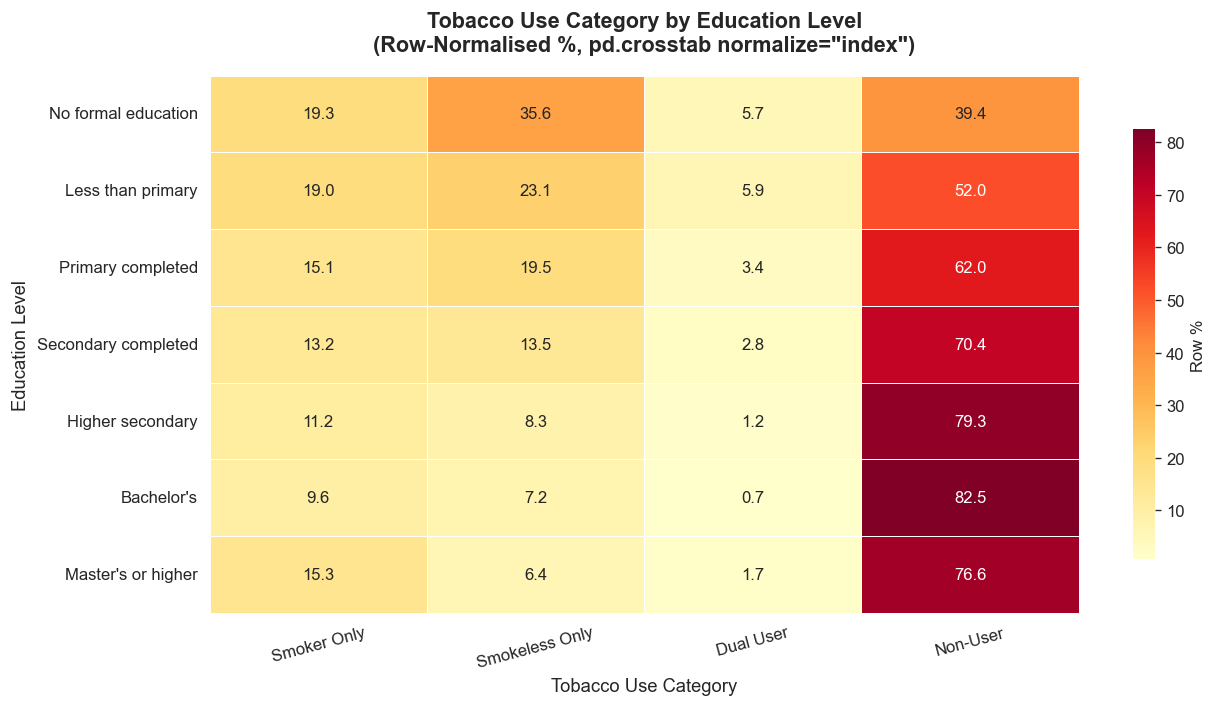


Raw cross-tabulation (row-normalised %):
Tobacco_Type         Smoker Only  Smokeless Only  Dual User  Non-User
Education                                                            
No formal education         19.3            35.6        5.7      39.4
Less than primary           19.0            23.1        5.9      52.0
Primary completed           15.1            19.5        3.4      62.0
Secondary completed         13.2            13.5        2.8      70.4
Higher secondary            11.2             8.3        1.2      79.3
Bachelor's                   9.6             7.2        0.7      82.5
Master's or higher          15.3             6.4        1.7      76.6


In [ ]:
# 4.12a Education × Tobacco Type — Row-Normalised Cross-Tab Heatmap
edu_order_plot = [
    'No formal education', 'Less than primary', 'Primary completed',
    'Secondary completed', 'Higher secondary', "Bachelor's", "Master's or higher"
]
type_order_plot = ['Smoker Only', 'Smokeless Only', 'Dual User', 'Non-User']

edu_tob_ct = pd.crosstab(
    df['Education'], df['Tobacco_Type'], normalize='index'
) * 100

# Reindex to enforce logical ordering and drop NaN education rows
edu_tob_ct = edu_tob_ct.reindex(index=edu_order_plot, columns=type_order_plot).dropna(how='all')

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(
    edu_tob_ct,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Row %', 'shrink': 0.8},
    ax=ax
)
ax.set_title(
    'Tobacco Use Category by Education Level\n(Row-Normalised %, pd.crosstab normalize="index")',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Tobacco Use Category', fontsize=11)
ax.set_ylabel('Education Level', fontsize=11)
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('15_edu_tobacco_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRaw cross-tabulation (row-normalised %):")
print(edu_tob_ct.round(1).to_string())


### 4.13b Daily Cigarette Consumption (B04) by Age Group

Grouped box plots show whether the *quantity* of cigarettes smoked per day varies with age,
which has implications for targeted cessation interventions.


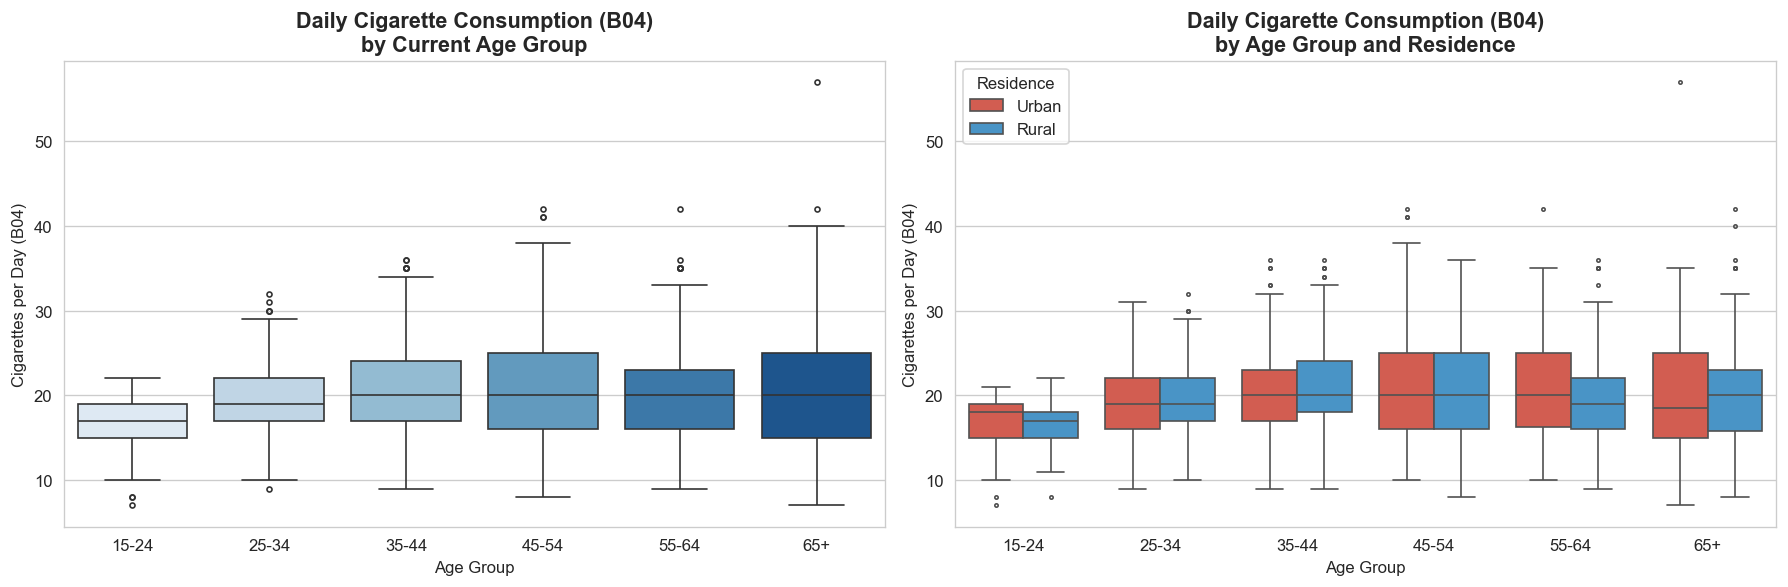

Daily smokers in analysis: 2,224

Median cigarettes/day (B04) by age group:
Age_Group
15-24    17.0
25-34    19.0
35-44    20.0
45-54    20.0
55-64    20.0
65+      20.0
Name: B04, dtype: float64


In [ ]:
# 4.13b Grouped Box Plot — Daily Cigarette Consumption (B04) by Age Group
# B04 = number of manufactured cigarettes smoked per day by daily smokers (B01==1)
# Sentinel values 77/99/999 (don't know/refused/not applicable) are excluded
daily_cig = df[(df['B01'] == 1) & (df['B04'].notna()) & (df['B04'] < 77)].copy()
daily_cig = daily_cig[daily_cig['Age_Group'].notna()]

age_group_order = ['15-24', '25-34', '35-44', '45-54', '55-64', '65+']
present_age_groups = [g for g in age_group_order if g in daily_cig['Age_Group'].values]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: grouped box plot by age group
sns.boxplot(
    data=daily_cig, x='Age_Group', y='B04',
    order=present_age_groups,
    palette='Blues', fliersize=3,
    ax=axes[0]
)
axes[0].set_title('Daily Cigarette Consumption (B04)\nby Current Age Group',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Cigarettes per Day (B04)')

# Right: grouped box plot by age group AND residence (urban/rural)
sns.boxplot(
    data=daily_cig[daily_cig['Residence'].notna()],
    x='Age_Group', y='B04', hue='Residence',
    order=present_age_groups,
    palette={'Urban': '#e74c3c', 'Rural': '#3498db'},
    fliersize=2, ax=axes[1]
)
axes[1].set_title('Daily Cigarette Consumption (B04)\nby Age Group and Residence',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Cigarettes per Day (B04)')
axes[1].legend(title='Residence', frameon=True)

plt.tight_layout()
plt.savefig('16_boxplot_cigs_age.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Daily smokers in analysis: {len(daily_cig):,}")
print("\nMedian cigarettes/day (B04) by age group:")
print(daily_cig.groupby('Age_Group', observed=True)['B04'].median().round(1))


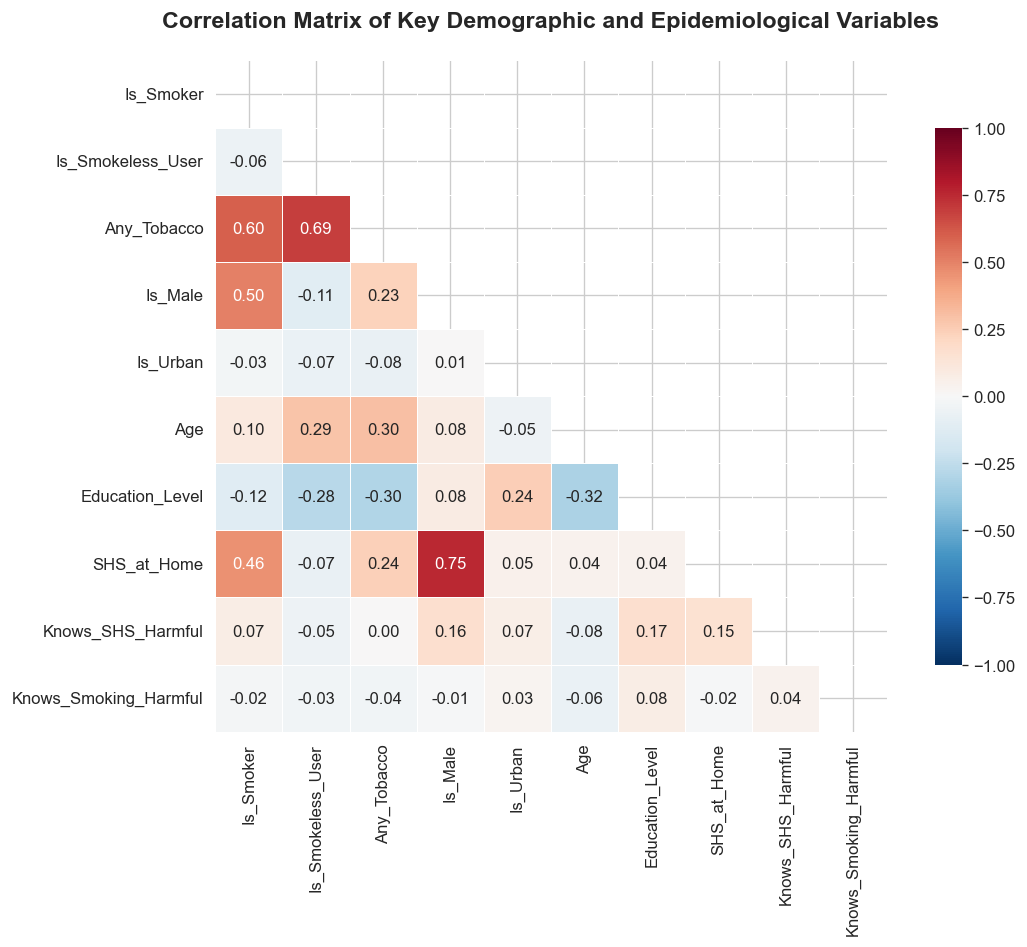

In [ ]:
# 4.12 Correlation Matrix and Heatmap
corr_df = pd.DataFrame({
    'Is_Smoker': df['B01'].isin([1,2]).astype(int),
    'Is_Smokeless_User': df['C01'].isin([1,2]).astype(int),
    'Any_Tobacco': (df['Any_Tobacco'] == 'Tobacco User').astype(int),
    'Is_Male': (df['A01'] == 1).astype(int),
    'Is_Urban': (df['RESIDENCE'] == 1).astype(int),
    'Age': df['AGE'],
    'Education_Level': df['A04'],
    'SHS_at_Home': (df['E04'] == 1).astype(int),
    'Knows_SHS_Harmful': (df['E15'] == 1).astype(int),
    'Knows_Smoking_Harmful': (df['H01'] == 1).astype(int),
})

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix of Key Demographic and Epidemiological Variables', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('12_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


Key correlations from the matrix:

- **Male gender and smoking ($r = 0.50$):** Strong positive correlation confirming that smoking is concentrated among men.
- **Male gender and home SHS ($r = 0.75$):** Strong correlation linked to shared indoor smoking among male peers.
- **Education and smokeless use ($r = -0.28$):** Negative correlation showing that higher education protects against smokeless tobacco.
- **Age and any tobacco ($r = 0.30$):** Moderate positive correlation reflecting higher use in older age groups.
- **Smoking and smokeless use ($r = -0.06$):** Near-zero correlation indicates that smoking and smokeless tobacco are independent habits with different target populations.

### 4.13 Multivariate Exploration

This section examines age distributions and logistic regression curves for smoking and smokeless tobacco.


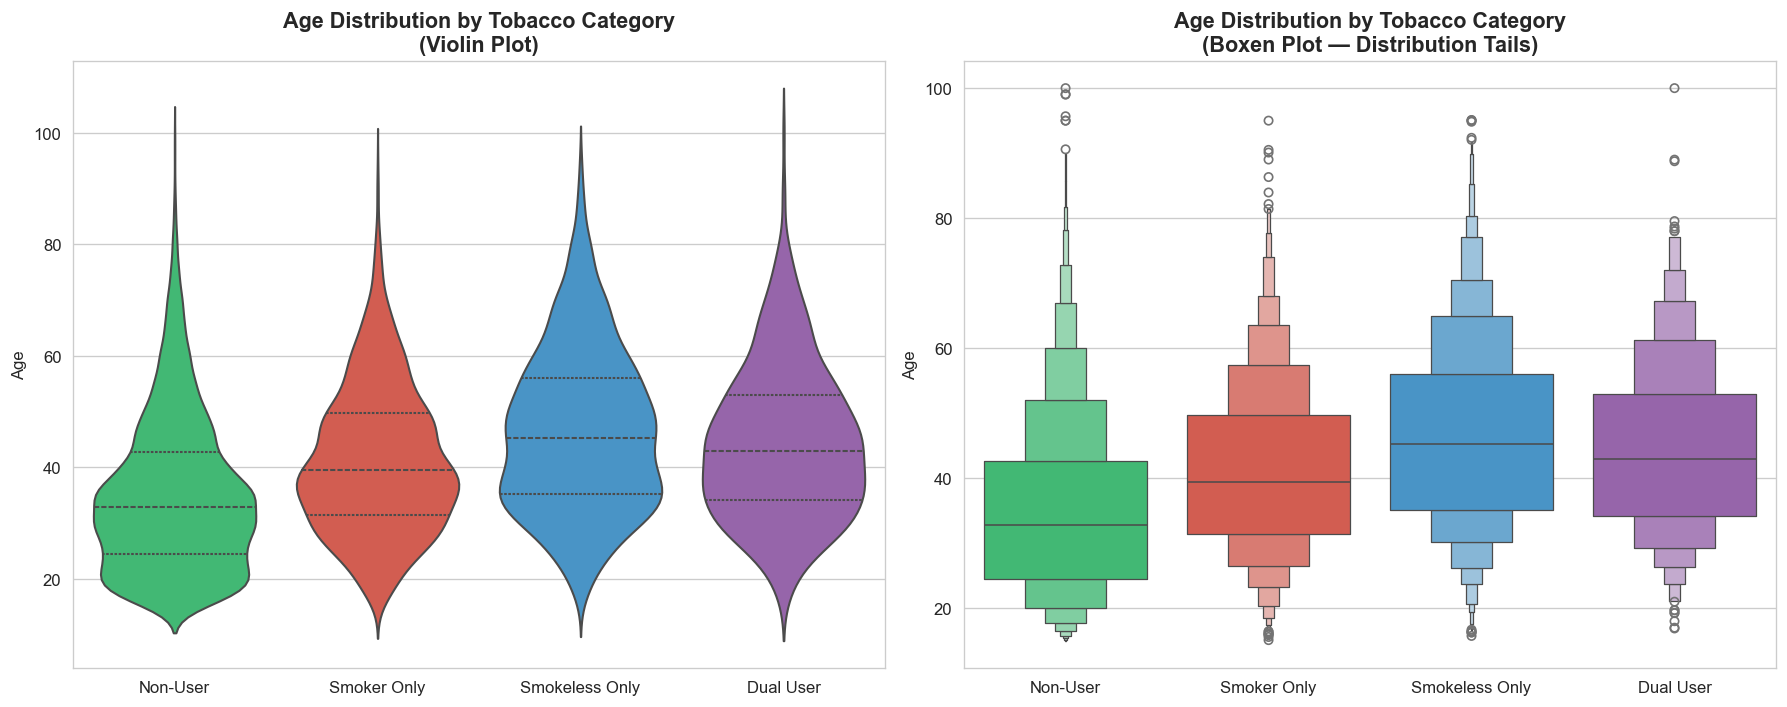

In [ ]:
# 4.13 Multivariate Distributions (Violin and Boxen Plots)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

type_order = ['Non-User', 'Smoker Only', 'Smokeless Only', 'Dual User']

sns.violinplot(data=df, x='Tobacco_Type', y='AGE', order=type_order,
               palette=['#2ecc71', '#e74c3c', '#3498db', '#9b59b6'],
               inner='quartile', ax=axes[0])
axes[0].set_title('Age Distribution by Tobacco Category\n(Violin Plot)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Age')

sns.boxenplot(data=df, x='Tobacco_Type', y='AGE', order=type_order,
              palette=['#2ecc71', '#e74c3c', '#3498db', '#9b59b6'], ax=axes[1])
axes[1].set_title('Age Distribution by Tobacco Category\n(Boxen Plot — Distribution Tails)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.savefig('13_violin_boxen.png', dpi=150, bbox_inches='tight')
plt.show()


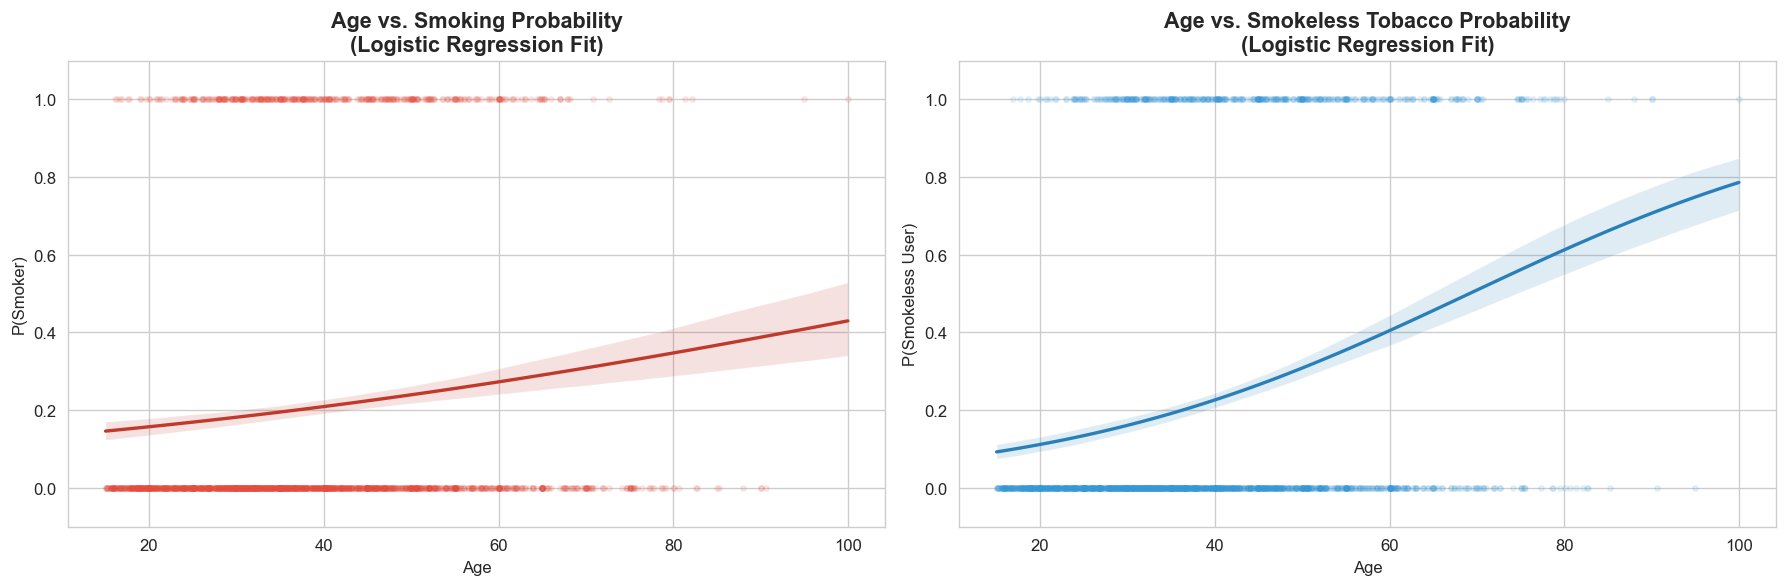

In [ ]:
# 4.13 Logistic Regression Fits (Age vs. Probability)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sample = df.sample(n=2000, random_state=42).copy()
sample['Is_Smoker'] = sample['B01'].isin([1,2]).astype(int)
sample['Is_Smokeless'] = sample['C01'].isin([1,2]).astype(int)

sns.regplot(data=sample, x='AGE', y='Is_Smoker', logistic=True,
            scatter_kws={'alpha': 0.1, 's': 10, 'color': '#e74c3c'},
            line_kws={'color': '#c0392b', 'linewidth': 2}, ax=axes[0])
axes[0].set_title('Age vs. Smoking Probability\n(Logistic Regression Fit)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('P(Smoker)')
axes[0].set_ylim(-0.1, 1.1)

sns.regplot(data=sample, x='AGE', y='Is_Smokeless', logistic=True,
            scatter_kws={'alpha': 0.1, 's': 10, 'color': '#3498db'},
            line_kws={'color': '#2980b9', 'linewidth': 2}, ax=axes[1])
axes[1].set_title('Age vs. Smokeless Tobacco Probability\n(Logistic Regression Fit)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('P(Smokeless User)')
axes[1].set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.savefig('14_regplot_age.png', dpi=150, bbox_inches='tight')
plt.show()


Insights from the multivariate and regression models:

- **Distribution shapes:** Violin and boxen plots confirm that smokeless users skew older, while non-users are youngest.
- **Logistic regression curves:** The probability of smokeless tobacco use increases steadily with age. Smoking probability shows a curved pattern, rising early and leveling off in later years.
- **Intervention focus:** Anti-smoking campaigns should target young adults (ages 20–35). Smokeless tobacco programs should target middle-aged and older adults.

### 4.14 Summary Statistics Table

This table provides a quick reference for all primary statistics from the GATS 2017 analysis.


In [ ]:
# 4.14 Summary Statistics Table Display
summary_data = {
    'Metric': [
        'Total respondents',
        'Male / Female',
        'Urban / Rural',
        '---',
        'Current smokers (daily + occasional)',
        'Current smokeless tobacco users',
        'Dual users (both)',
        'Any tobacco users',
        '---',
        'Male smoking rate',
        'Female smoking rate',
        'Male smokeless rate',
        'Female smokeless rate',
        '---',
        'SHS exposure at home (among valid)',
        'Know smoking causes illness',
        'Know SHS is harmful',
        'Awareness gap (smoking vs SHS)',
        '---',
        'Median smoking initiation age',
        '% started smoking before age 18',
    ],
    'Value': [
        f'{len(df):,}',
        f'{(df["A01"]==1).sum():,} / {(df["A01"]==2).sum():,}',
        f'{(df["RESIDENCE"]==1).sum():,} / {(df["RESIDENCE"]==2).sum():,}',
        '',
        f'{df["B01"].isin([1,2]).sum():,} ({df["B01"].isin([1,2]).sum()/len(df)*100:.1f}%)',
        f'{df["C01"].isin([1,2]).sum():,} ({df["C01"].isin([1,2]).sum()/len(df)*100:.1f}%)',
        f'{(df["Tobacco_Type"]=="Dual User").sum():,} ({(df["Tobacco_Type"]=="Dual User").sum()/len(df)*100:.1f}%)',
        f'{(df["Any_Tobacco"]=="Tobacco User").sum():,} ({(df["Any_Tobacco"]=="Tobacco User").sum()/len(df)*100:.1f}%)',
        '',
        f'{df[(df["A01"]==1) & df["B01"].isin([1,2])].shape[0] / (df["A01"]==1).sum()*100:.1f}%',
        f'{df[(df["A01"]==2) & df["B01"].isin([1,2])].shape[0] / (df["A01"]==2).sum()*100:.1f}%',
        f'{df[(df["A01"]==1) & df["C01"].isin([1,2])].shape[0] / (df["A01"]==1).sum()*100:.1f}%',
        f'{df[(df["A01"]==2) & df["C01"].isin([1,2])].shape[0] / (df["A01"]==2).sum()*100:.1f}%',
        '',
        f'{(df["E04"]==1).sum():,} ({(df["E04"]==1).sum()/(df["E04"].isin([1,2])).sum()*100:.1f}%)',
        f'{(df["H01"]==1).sum():,} ({(df["H01"]==1).sum()/df["H01"].notna().sum()*100:.1f}%)',
        f'{(df["E15"]==1).sum():,} ({(df["E15"]==1).sum()/len(df)*100:.1f}%)',
        f'{(df["H01"]==1).sum()/df["H01"].notna().sum()*100 - (df["E15"]==1).sum()/len(df)*100:.1f} percentage points',
        '',
        f'{df[(df["B01"]==1) & (df["B06A"].notna()) & (df["B06A"]<77) & (df["B06A"]>0)]["B06A"].median():.0f} years',
        f'{(df[(df["B01"]==1) & (df["B06A"].notna()) & (df["B06A"]<77) & (df["B06A"]>0)]["B06A"] < 18).sum() / len(df[(df["B01"]==1) & (df["B04"].notna()) & (df["B04"]<77)]) * 100:.1f}%',
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.replace('---', '')
print(summary_df.to_string(index=False))


                              Metric                  Value
                   Total respondents                 12,783
                       Male / Female          6,079 / 6,704
                       Urban / Rural          6,356 / 6,427
                                                           
Current smokers (daily + occasional)          2,493 (19.5%)
     Current smokeless tobacco users          3,119 (24.4%)
                   Dual users (both)             484 (3.8%)
                   Any tobacco users          5,128 (40.1%)
                                                           
                   Male smoking rate                  40.3%
                 Female smoking rate                   0.6%
                 Male smokeless rate                  19.2%
               Female smokeless rate                  29.1%
                                                           
  SHS exposure at home (among valid)          5,752 (45.0%)
         Know smoking causes illness    

## 5. Key Findings and Discussion <a id="5-key-findings-and-discussion"></a>

The analysis highlights seven major findings:

### Finding 1: High Burden of Smokeless Tobacco
Smokeless tobacco use (24.4%) exceeds cigarette smoking (19.5%). Products like *zarda* and *sadapata* are widely used but receive less policy attention.

### Finding 2: Sharp Gender Division by Product Type
Men predominantly smoke (~40%). Women predominantly use smokeless tobacco (~29%). Measuring only cigarette smoking undercounts the health burden among women.

### Finding 3: Secondhand Smoke Awareness Gap
96.7% of adults know smoking is harmful. Only 54.1% know secondhand smoke harms non-smokers. This 42.6 percentage point gap is a prime target for public education.

### Finding 4: Smoking and Smokeless Use are Separate Epidemics
The correlation between smoking and smokeless use is nearly zero ($r = -0.06$). They affect different demographic groups and require distinct interventions.

### Finding 5: Early Smoking Initiation
The median age of smoking initiation is 18 years. Lower educational attainment correlates with earlier initiation ages.

### Finding 6: Education Protects Against Tobacco Use
Tobacco prevalence drops from ~50% among uneducated adults to ~24% among postgraduates. Health literacy is a powerful long-term protective factor.

### Finding 7: Homes Lack Smoking Restrictions
Most homes have no indoor smoking rules. Because homes are private spaces, public education is essential to encourage smoke-free households.


## 6. Policy Implications <a id="6-policy-implications"></a>

Based on the evidence, seven policy actions are recommended:

1. **Regulate smokeless tobacco equally:** Apply the same health warnings, taxes, and packaging rules to smokeless products as cigarettes.
2. **Launch a national secondhand smoke campaign:** Educate the public on the dangers of secondhand smoke to close the 42.6 percentage point awareness gap.
3. **Start school prevention programs early:** Introduce anti-tobacco education in primary and middle schools before the median initiation age of 18.
4. **Design gender-specific programs:** Focus male programs on smoking cessation. Focus female programs on smokeless tobacco in rural and semi-urban communities.
5. **Enforce smoke-free laws in public places:** Strengthen enforcement in restaurants, workplaces, and public transit.
6. **Use adult education channels:** Integrate tobacco harm awareness into adult literacy programs.
7. **Allocate resources regionally:** Direct more public health funding to divisions with higher tobacco prevalence.

These actions directly support **UN Sustainable Development Goal 3 (Target 3.a)**.


## 7. Limitations <a id="7-limitations"></a>

Several study limitations should be noted:

- **Self-reported data:** Survey responses may suffer from recall bias or underreporting, especially among women.
- **Cross-sectional design:** The data captures a single point in time (2017). It shows associations but cannot prove causality.
- **Unweighted analysis:** This exploratory analysis uses unweighted sample counts. Values may differ slightly from complex survey-weighted national estimates.
- **Unmeasured variables:** Detailed household income and specific product brand details were not included in this analysis.


## 8. Conclusion <a id="8-conclusion"></a>

The 2017 GATS data shows that tobacco use in Bangladesh is widespread and diverse:

- **Prevalence is high:** About 40% of adults consume tobacco products.
- **Smokeless tobacco dominates:** It is the primary form of tobacco for women and older adults.
- **Secondhand smoke awareness is low:** A large knowledge gap remains regarding the harms of secondhand smoke.
- **Education protects health:** Higher education strongly correlates with lower tobacco use.
- **Intervention must start young:** Most smokers start before age 18.

Reducing this burden requires a balanced approach. Bangladesh needs strict policy enforcement, early school education, and gender-targeted cessation programs to advance UN SDG 3.


## 9. References <a id="9-references"></a>

1. World Health Organization. (2019). *Global Adult Tobacco Survey (GATS): Bangladesh 2017 — Country Report*. WHO Regional Office for South-East Asia.

2. World Health Organization. (2023). *Tobacco Fact Sheet*. Retrieved from https://www.who.int/news-room/fact-sheets/detail/tobacco

3. Bangladesh Bureau of Statistics (BBS) & National Tobacco Control Cell. (2019). *Global Adult Tobacco Survey: Bangladesh Report 2017*.

4. Centers for Disease Control and Prevention (CDC). *Global Tobacco Surveillance System Data (GTSSData)*. Retrieved from https://nccd.cdc.gov/GTSSDataSurveyResources/

5. United Nations. *Sustainable Development Goal 3: Good Health and Well-being*. Retrieved from https://sdgs.un.org/goals/goal3

6. WHO Framework Convention on Tobacco Control (FCTC). Retrieved from https://fctc.who.int/

---

**Dataset Information:**
- **Title:** Bangladesh Global Adult Tobacco Survey (GATS) 2017 — Public Use Data File
- **File:** `Bangla_GATS_2017_Public_use_06Spe2018.csv`
- **Rows:** 12,783
- **Columns:** 516
- **Numeric Columns:** 498
- **String Columns:** 18
- **Source:** WHO GATS Data Repository / CDC GTSS Portal


---

## Appendix: Dataset Information Card
*Course Submission Summary*

| Field | Description / Value |
|-------|---------------------|
| **Topic** | Tobacco Use Patterns and Secondhand Smoke Exposure in Bangladesh |
| **SDG Alignment** | SDG 3 — Good Health and Well-being (Target 3.a) |
| **Dataset Name** | Bangladesh Global Adult Tobacco Survey (GATS) 2017 — Public Use File |
| **Data Repository** | [CDC GTSS Data Portal](https://nccd.cdc.gov/GTSSDataSurveyResources/) |
| **Total Rows** | 12,783 |
| **Total Columns** | 516 |
| **Numeric Columns** | 498 (int64: 59, float64: 439) |
| **Non-Numeric Columns** | 18 (string/object type) |
| **Missing Cells** | 4,423,173 cells (67.06% — conditional skip patterns) |
| **Complete Columns** | 61 |
| **Conditional Columns** | 455 |
| **Sample Weight Variable** | `gatsweight` |

### Chart Types and Analytical Methods

| Chart Type | Implementation | Purpose |
|------------|----------------|---------|
| Count Plot | `sns.countplot` | Distribution of tobacco categories and awareness indicators |
| Bar Plot / Horizontal Bar | `sns.barplot`, `df.plot.barh()` | Prevalence by gender, age, education, and SHS setting |
| Stacked Bar Chart | `df.plot.bar(stacked=True)`, matplotlib | Division-wise and gender-stratified composition |
| Point Plot | `sns.pointplot` | Prevalence trends across age cohorts |
| Histogram + KDE | `sns.histplot` | Distribution of smoking initiation age |
| Kernel Density Estimate (KDE) | `sns.kdeplot` | Age density comparison across user categories |
| Box Plot | `sns.boxplot` | Smoking initiation age by education level |
| Violin Plot | `sns.violinplot` | Age distributions by tobacco category |
| Boxen Plot | `sns.boxenplot` | Distribution tails across user categories |
| Correlation Heatmap | `sns.heatmap` | Linear association matrix across variables |
| Logistic Regression Plot | `sns.regplot` | Tobacco use probability modeled by age |
